# Tutorial: Inner-to-Outer Follicle Gradient Analysis

This notebook applies the MINGL gradient-analysis workflow to the Inner Follicle and Outer Follicle cell neighborhood transition in the healthy human intestine. It begins with centroid and Gaussian-mixture scoring, then derives probability ratio scores, a metric of transition "steepness", bins cells along the gradient, and generates downstream composition and graph summaries.

Expected manuscript-aligned findings:
- high Inner Follicle enrichment at the follicle center
- increasing CD4+ T-cell representation toward the periphery
- a mixed intermediate zone with both follicle programs present
- steep local gradient magnitudes concentrated near the follicle interface

Main user-adjustable controls:
- the two neighborhoods being contrasted (`tu1` and `tu2`)
- the metadata columns used in the gradient workflow
- the number of bins, bin labels, clustering parameters, and neighborhood window sizes
- selected target regions, palettes, and plotting scales

**Update timestamp:** 2026-03-19 15:48:31 -04:00


## 0. Import dependencies

Load the libraries used throughout this notebook for neighborhood-level intestine workflow.


In [1]:
import anndata as ad
import pandas as pd
import numpy as np
import mingl as mg
import seaborn as sns
import matplotlib.pyplot as plt

## 1. Load the fast dataset

Read the intestine spatial table into an `AnnData` object and inspect the imported observation metadata before setting the analysis columns.


In [2]:
file_path = r"Z:\MINGLE\Reviewer Response\Code\R1.5\synthetic_tissue_slow.csv"
cells = mg.pp.read_file(file_path)

c:\Users\k1van\anaconda3\envs\mingle-env\Lib\functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


## 2. Define the cellular community columns for downstream analysis

Set the neighborhood, community, and region columns passed into the core MINGL functions.

Motivation:
These variables control both the biological resolution of the model and the geometric boundaries used when constructing KNN windows.

User-adjustable arguments:
- `cluster_col`: local composition feature space used by `KNN2` and `centroid_Calculation`
- `neighborhood_col`: label being modeled as the target neighborhood assignment
- `region_key`: passed to `KNN2` to keep windows inside each tissue region

Related source files:
- `src/mingl/tl/knn2.py`
- `src/mingl/tl/centroids.py`
- `src/mingl/tl/gmm.py`

The ``cluster_col`` will here be the column for cell types.

The ``neighborhood_col`` here will be the column for cellular neighborhoods, since this is the level that we will perform our gradient analysis and we will need neighborhood membership probabilities to enable the gradient analysis at this hierarchical level.


In [3]:
cells.obs

,cell_id,x,y,cell_type,unique_region,true_organization,Neighborhood
0,0,850.585467,931.366005,2,1,B,B
1,1,451.564956,166.936956,11,1,A,A
2,2,248.735975,591.645276,12,1,A,B
3,3,584.153406,326.727948,4,1,B,B
4,4,663.688130,711.389394,4,1,B,B
...,...,...,...,...,...,...,...
3335,3335,239.822385,29.471294,3,1,A,A
3336,3336,442.628147,727.556213,7,1,A,A
3337,3337,440.154406,240.954546,1,1,A,B
3338,3338,3.745708,397.898635,10,1,A,A


In [4]:
cluster_col = "cell_type"
neighborhood_col = "Neighborhood"
region_key = "unique_region"

## 3. Compute neighborhood centroids

R`mg.tl.centroid_Calculation` in `src/mingl/tl/centroids.py` summarizes local cellular composition around each annotated neighborhood.

Motivation:
The code below creates the reference centroid matrix used by the later GMM probability calculation.

User-adjustable arguments:
- `k`: neighborhood size
- `cluster_col`: feature labels counted within windows
- `neighborhood_col`: neighborhood grouping variable
- `region_col`: region boundary variable
- `store_key`: optional cache key if you want to retain the centroid object in `adata.uns`

Practical guidance:
- larger `k` captures broader context but can blur sharp boundaries
- smaller `k` is more local but may be noisier
- k=10 for neighborhood centroids
- k=100 for community centroids
- k=300 for tissue unit centroids


In [5]:
print(cells.obs["cell_type"].dtype)

int64


In [6]:
cells.obs["cell_type"] = cells.obs["cell_type"].astype(str)

In [7]:
centroids = mg.tl.centroid_Calculation(cells, cluster_col=cluster_col, neighborhood_col=neighborhood_col, region_col=region_key, store_key="neighborhood_centroids")

Example dummy cols: ['cell_type__1', 'cell_type__10', 'cell_type__11', 'cell_type__12', 'cell_type__2']
{5:                x           y  unique_region cell_type    1   10   11   12  \
0     850.585467  931.366005              1         2  0.0  0.0  0.0  1.0   
1     451.564956  166.936956              1        11  0.0  1.0  1.0  0.0   
2     248.735975  591.645276              1        12  2.0  0.0  0.0  1.0   
3     584.153406  326.727948              1         4  0.0  0.0  2.0  0.0   
4     663.688130  711.389394              1         4  1.0  0.0  0.0  0.0   
...          ...         ...            ...       ...  ...  ...  ...  ...   
3335  239.822385   29.471294              1         3  2.0  1.0  0.0  0.0   
3336  442.628147  727.556213              1         7  1.0  0.0  0.0  0.0   
3337  440.154406  240.954546              1         1  1.0  0.0  1.0  0.0   
3338    3.745708  397.898635              1        10  0.0  2.0  1.0  1.0   
3339  299.828615  844.098963              1  

c:\Users\k1van\anaconda3\envs\mingle-env\Lib\site-packages\pandas\io\formats\format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()
c:\Users\k1van\anaconda3\envs\mingle-env\Lib\site-packages\pandas\io\formats\format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()
c:\Users\k1van\anaconda3\envs\mingle-env\Lib\site-packages\pandas\io\formats\format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()
c:\Users\k1van\anaconda3\envs\mingle-env\Lib\site-packages\pandas\io\formats\format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()
c:\Users\k1van\anaconda3\envs\mingle-env\Lib\site-packages\pandas\io\formats\format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()


## 4. Compute cluster membership probabilities

Run `mg.tl.cpu_gmm_probability` from `src/mingl/tl/gmm.py` to estimate each cell's probability of membership across the annotated neighborhoods.

Motivation:
This produces the central output used by the rest of the notebook: the per-cell neighborhood probability matrix in `adata.obsm`.

User-adjustable arguments:
- `cluster_col`, `neighborhood_col`, `region_key`: analysis metadata
- `ks` and `k`: available and selected neighborhood sizes
- `num_processes`: CPU parallelism, choose the number of CPU cores that you would like to use to parallelize this calculation. Do not use specify more cores than your machine has. The default is to use the total number of cores from your machine. 

Important implementation note:
The source stores probabilities in `adata.obsm[prob_key]` and stores neighborhood names in `adata.uns[prob_variable_key]`. You must set your ``prob_key`` and ``prob_variable_key`` to be unique for each level that you run analysis (i.e., "neighborhood_probabilities" for neighborhood level and "community_probabilities for community level etc.).

This step may take a while when using CPU, therefore, we have also created a GPU accelerated version of this step. In order to access it in the package, you will need to load it in separately using ``import mingl.tl.gmm_gpu as gpu_gmm``. Importantly, this requires your installation of ``cupy`` into your `mingle-hl` environment and access to a GPU on your machine.

In this example notebook, we will use the GPU version of MINGL.

In [ ]:
# CPU version of MINGL
#mg.tl.cpu_gmm_probability(CELLS_ADATA=cells, CENTROIDS_ADATA=centroids, cluster_col=cluster_col, neighborhood_col=neighborhood_col, region_key=region_key)

In [8]:
# GPU accelerated version of MINGL gmm

import mingl.tl.gmm_gpu as gpu_gmm

gpu_gmm.gpu_gmm_probability(cells, centroids, cluster_col= cluster_col, neighborhood_col= neighborhood_col, region_key= region_key, k= 10, 
                            batch_size= 20000, prob_key = 'neighborhood_probabilities', prob_variable_key = "neighborhood_probability_neighborhoods")

Example dummy cols: ['cell_type__1', 'cell_type__10', 'cell_type__11', 'cell_type__12', 'cell_type__2']
GPU Processing batch 1/1...


AnnData object with n_obs × n_vars = 3340 × 0
    obs: 'cell_id', 'x', 'y', 'cell_type', 'unique_region', 'true_organization', 'Neighborhood', 'B', 'A'
    uns: 'neighborhood_centroids', 'neighborhood_probability_neighborhoods'
    obsm: 'neighborhood_probabilities'

## 5. Count positive neighborhood memberships

Use `mg.tl.findPositives` to summarize how many neighborhood probabilities exceed the selected threshold for each cell.

Importantly, you must change the ``prob_key`` to match the adata.obsm probability key above. Also, if you plan to run this analysis at multiple levels, ensure you have a unique ``result_key`` such as "neighborhood_Count_Above_Threshold".

In [9]:
mg.tl.findPositives(cells)

AnnData object with n_obs × n_vars = 3340 × 0
    obs: 'cell_id', 'x', 'y', 'cell_type', 'unique_region', 'true_organization', 'Neighborhood', 'B', 'A', 'Count_Above_Threshold'
    uns: 'neighborhood_centroids', 'neighborhood_probability_neighborhoods'
    obsm: 'neighborhood_probabilities'

## 6. Save and reload processed results

Save your `AnnData` object with the data you have calculated. Specify the file path where you would like to save your data.


In [38]:
cells.write_h5ad("simslow_results.h5ad", compression="gzip")

If you have to pause here and come back at a later time, you can load your saved data back in later.

In [ ]:
cells = ad.read_h5ad("simslow_results.h5ad")

## 7. Investigate the probability table

Convert the stored probability matrix into a dataframe aligned to the original observations to check for sparcity, infinate values, or NaNs.

Convert the stored probability matrix into a `DataFrame` for gradient-oriented downstream analysis.


In [11]:
df_probabilities = pd.DataFrame(
    cells.obsm["neighborhood_probabilities"],
    index=cells.obs_names,  # restores cell index
    columns=cells.uns["neighborhood_probability_neighborhoods"]
)
df_probabilities

,B,A
0,0.998352,0.001648
1,0.738027,0.261973
2,0.782466,0.217534
3,0.998470,0.001530
4,0.988380,0.011620
...,...,...
3335,0.000076,0.999924
3336,0.002153,0.997847
3337,0.920343,0.079657
3338,0.000057,0.999943


## 8. Define the Inner Follicle and Outer Follicle comparison

Select the two units of interest and append the metadata columns required for downstream plotting.

Here, we are interested in the *Inner Follicle* and *Outer Follicle* communities.


In [12]:
# Define units of interest
tu1 = "A"
tu2 = "B"

# Additional columns needed downstream
extra_cols = ['x','y','unique_region','Neighborhood','cell_type','true_organization']

# Create new dataframe
df2 = cells.obs[extra_cols].copy()
df2[tu1] = df_probabilities[tu1]
df2[tu2] = df_probabilities[tu2]

df2


,x,y,unique_region,Neighborhood,cell_type,true_organization,A,B
0,850.585467,931.366005,1,B,2,B,0.001648,0.998352
1,451.564956,166.936956,1,A,11,A,0.261973,0.738027
2,248.735975,591.645276,1,B,12,A,0.217534,0.782466
3,584.153406,326.727948,1,B,4,B,0.001530,0.998470
4,663.688130,711.389394,1,B,4,B,0.011620,0.988380
...,...,...,...,...,...,...,...,...
3335,239.822385,29.471294,1,A,3,A,0.999924,0.000076
3336,442.628147,727.556213,1,A,7,A,0.997847,0.002153
3337,440.154406,240.954546,1,B,1,A,0.079657,0.920343
3338,3.745708,397.898635,1,A,10,A,0.999943,0.000057


## 9. Compute ratio-based gradient scores

Calculate ratio and log-ratio summaries to position each cell along the Inner-to-Outer continuum.

Expected interpretation:
One end of the score range corresponds to inner follicle-dominant local context, while the opposite end corresponds to outer follicle context. Near-zero values represent mixed local composition.


In [13]:
# ratio with small constant to avoid division by zero
eps = 1e-9
df2["ratio"] = (df2[tu1] + eps) / (df2[tu2] + eps)

# log ratio
df2["log_ratio"] = np.log(df2["ratio"])

# max probability
df2["max_prob"] = df2[[tu1, tu2]].max(axis=1)

# final score
df2["Score"] = df2["log_ratio"] * df2["max_prob"]

df2

,x,y,unique_region,Neighborhood,cell_type,true_organization,A,B,ratio,log_ratio,max_prob,Score
0,850.585467,931.366005,1,B,2,B,0.001648,0.998352,0.001650,-6.406739,0.998352,-6.396182
1,451.564956,166.936956,1,A,11,A,0.261973,0.738027,0.354964,-1.035740,0.738027,-0.764404
2,248.735975,591.645276,1,B,12,A,0.217534,0.782466,0.278011,-1.280095,0.782466,-1.001630
3,584.153406,326.727948,1,B,4,B,0.001530,0.998470,0.001532,-6.481222,0.998470,-6.471308
4,663.688130,711.389394,1,B,4,B,0.011620,0.988380,0.011756,-4.443352,0.988380,-4.391721
...,...,...,...,...,...,...,...,...,...,...,...,...
3335,239.822385,29.471294,1,A,3,A,0.999924,0.000076,13119.537249,9.481858,0.999924,9.481135
3336,442.628147,727.556213,1,A,7,A,0.997847,0.002153,463.507797,6.138823,0.997847,6.125607
3337,440.154406,240.954546,1,B,1,A,0.079657,0.920343,0.086552,-2.447015,0.920343,-2.252093
3338,3.745708,397.898635,1,A,10,A,0.999943,0.000057,17512.709307,9.770682,0.999943,9.770124


## 10. Bin cells along the probability gradient

Define helper functions that discretize the continuous gradient score into interpretable bins.

Why this matters:
The manuscript compares gradients across biological scales. Using ordered bins makes it possible to compare the shape of this transition directly against other transition or border cases.


In [14]:
def _percentile_labels(n_bins):
    step = 100 / n_bins
    return [f"{int((i + 1) * step)}th percentile" for i in range(n_bins)]

def assign_probability_level_equal_width(series, n_bins=5):
    """
    Split non-missing rows into `n_bins` equal-width bins based on
    the numeric score range (min → max).

    Returns:
      - pd.Series (categorical) with percentile-style labels
      - numpy.ndarray of numeric edges:
            [left_edge_bin1, ..., right_edge_binK]

    NaNs are preserved.
    """

    idx = series.index
    s_non_na = series.dropna()

    if len(s_non_na) == 0:
        labels = _percentile_labels(n_bins)
        cat = pd.Series(
            pd.Categorical([np.nan] * len(series), categories=labels, ordered=True),
            index=idx
        )
        return cat, np.array([])

    # Compute equal-width edges
    min_val = float(s_non_na.min())
    max_val = float(s_non_na.max())

    if min_val == max_val:
        # All values identical → single bin
        labels = _percentile_labels(1)
        cat = pd.Series(
            pd.Categorical(
                [labels[0] if not pd.isna(v) else np.nan for v in series],
                categories=labels,
                ordered=True
            ),
            index=idx
        )
        return cat, np.array([min_val, max_val])

    edges = np.linspace(min_val, max_val, n_bins + 1)

    labels = _percentile_labels(n_bins)

    # Create categorical bins
    binned = pd.cut(
        series,
        bins=edges,
        labels=labels,
        include_lowest=True
    )

    # Debug output
    counts = binned.value_counts(dropna=True).sort_index()
    print("Counts per bin:", counts.to_dict())
    print("Bin edges (equal-width):", edges)

    return binned, edges


In [15]:
# ---------------- Example usage ----------------
df2["Probability_Level"], edges_used = assign_probability_level_equal_width(df2["Score"], n_bins=5)
print(edges_used)
print(df2["Probability_Level"].value_counts(dropna=False))
df = df2
df

Counts per bin: {'20th percentile': 463, '40th percentile': 814, '60th percentile': 844, '80th percentile': 796, '100th percentile': 423}
Bin edges (equal-width): [-20.72326584 -12.4339595   -4.14465317   4.14465317  12.4339595
  20.72326584]
[-20.72326584 -12.4339595   -4.14465317   4.14465317  12.4339595
  20.72326584]
Probability_Level
60th percentile     844
40th percentile     814
80th percentile     796
20th percentile     463
100th percentile    423
Name: count, dtype: int64


,x,y,unique_region,Neighborhood,cell_type,true_organization,A,B,ratio,log_ratio,max_prob,Score,Probability_Level
0,850.585467,931.366005,1,B,2,B,0.001648,0.998352,0.001650,-6.406739,0.998352,-6.396182,40th percentile
1,451.564956,166.936956,1,A,11,A,0.261973,0.738027,0.354964,-1.035740,0.738027,-0.764404,60th percentile
2,248.735975,591.645276,1,B,12,A,0.217534,0.782466,0.278011,-1.280095,0.782466,-1.001630,60th percentile
3,584.153406,326.727948,1,B,4,B,0.001530,0.998470,0.001532,-6.481222,0.998470,-6.471308,40th percentile
4,663.688130,711.389394,1,B,4,B,0.011620,0.988380,0.011756,-4.443352,0.988380,-4.391721,40th percentile
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3335,239.822385,29.471294,1,A,3,A,0.999924,0.000076,13119.537249,9.481858,0.999924,9.481135,80th percentile
3336,442.628147,727.556213,1,A,7,A,0.997847,0.002153,463.507797,6.138823,0.997847,6.125607,80th percentile
3337,440.154406,240.954546,1,B,1,A,0.079657,0.920343,0.086552,-2.447015,0.920343,-2.252093,60th percentile
3338,3.745708,397.898635,1,A,10,A,0.999943,0.000057,17512.709307,9.770682,0.999943,9.770124,80th percentile


## 11. Prepare clustered probability-bin summaries

Use the gradient-derived table to generate the clustered summaries that feed into the later plots.


In [16]:
import re
import numpy as np
import pandas as pd
from sklearn.cluster import MiniBatchKMeans
import seaborn as sns
import matplotlib.pyplot as plt

# ---------- Settings / names ----------
ks = [10,20,30,50,100]
X = 'x'
Y = 'y'
reg = 'unique_region'
neigh = 'Neighborhood'
cluster_col = 'Probability_Level'   # e.g., "20th percentile", "40th percentile", ...
celltype = 'Cell Type'
tiss = 'Tissue Unit'
comm = 'Community'



In [17]:
df.reset_index(inplace=True, drop=True)
df

,x,y,unique_region,Neighborhood,cell_type,true_organization,A,B,ratio,log_ratio,max_prob,Score,Probability_Level
0,850.585467,931.366005,1,B,2,B,0.001648,0.998352,0.001650,-6.406739,0.998352,-6.396182,40th percentile
1,451.564956,166.936956,1,A,11,A,0.261973,0.738027,0.354964,-1.035740,0.738027,-0.764404,60th percentile
2,248.735975,591.645276,1,B,12,A,0.217534,0.782466,0.278011,-1.280095,0.782466,-1.001630,60th percentile
3,584.153406,326.727948,1,B,4,B,0.001530,0.998470,0.001532,-6.481222,0.998470,-6.471308,40th percentile
4,663.688130,711.389394,1,B,4,B,0.011620,0.988380,0.011756,-4.443352,0.988380,-4.391721,40th percentile
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3335,239.822385,29.471294,1,A,3,A,0.999924,0.000076,13119.537249,9.481858,0.999924,9.481135,80th percentile
3336,442.628147,727.556213,1,A,7,A,0.997847,0.002153,463.507797,6.138823,0.997847,6.125607,80th percentile
3337,440.154406,240.954546,1,B,1,A,0.079657,0.920343,0.086552,-2.447015,0.920343,-2.252093,60th percentile
3338,3.745708,397.898635,1,A,10,A,0.999943,0.000057,17512.709307,9.770682,0.999943,9.770124,80th percentile


## 12. Build dummy-coded local windows and neighborhood summaries

Create the local neighborhood representation used for grouped composition analysis.

Why this matters:
The later clustering and fold-change plots operate on neighborhood composition, not on single probabilities alone. This step reconstructs the local cellular context needed to connect gradient position to cell-type makeup.


In [18]:
# ---------- Preconditions ----------
if cluster_col not in df.columns:
    raise KeyError(f"Column '{cluster_col}' not found in df.")

# --- 1) Create dummies from the cluster_col and attach to df ---
dummies = pd.get_dummies(df[cluster_col], dtype=int)
df = pd.concat([df, dummies], axis=1)

# --- 2) Use the dummy column names as the summary columns everywhere ---
sum_cols2 = dummies.columns.tolist()
values = df[sum_cols2].values
df

,x,y,unique_region,Neighborhood,cell_type,true_organization,A,B,ratio,log_ratio,max_prob,Score,Probability_Level,20th percentile,40th percentile,60th percentile,80th percentile,100th percentile
0,850.585467,931.366005,1,B,2,B,0.001648,0.998352,0.001650,-6.406739,0.998352,-6.396182,40th percentile,0,1,0,0,0
1,451.564956,166.936956,1,A,11,A,0.261973,0.738027,0.354964,-1.035740,0.738027,-0.764404,60th percentile,0,0,1,0,0
2,248.735975,591.645276,1,B,12,A,0.217534,0.782466,0.278011,-1.280095,0.782466,-1.001630,60th percentile,0,0,1,0,0
3,584.153406,326.727948,1,B,4,B,0.001530,0.998470,0.001532,-6.481222,0.998470,-6.471308,40th percentile,0,1,0,0,0
4,663.688130,711.389394,1,B,4,B,0.011620,0.988380,0.011756,-4.443352,0.988380,-4.391721,40th percentile,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3335,239.822385,29.471294,1,A,3,A,0.999924,0.000076,13119.537249,9.481858,0.999924,9.481135,80th percentile,0,0,0,1,0
3336,442.628147,727.556213,1,A,7,A,0.997847,0.002153,463.507797,6.138823,0.997847,6.125607,80th percentile,0,0,0,1,0
3337,440.154406,240.954546,1,B,1,A,0.079657,0.920343,0.086552,-2.447015,0.920343,-2.252093,60th percentile,0,0,1,0,0
3338,3.745708,397.898635,1,A,10,A,0.999943,0.000057,17512.709307,9.770682,0.999943,9.770124,80th percentile,0,0,0,1,0


## 13. Compute neighborhood windows for the gradient workflow

Construct the neighborhood windows that support the `Neighborhoods` class and later cluster-level summaries.


In [19]:
import pandas as pd
import numpy as np
from sklearn.neighbors import NearestNeighbors
import time
import sys



class Neighborhoods(object):
    def __init__(self, cells,ks,cluster_col,sum_cols,keep_cols,neigh,X='X:X',Y = 'Y:Y',reg = 'Exp',add_dummies = True):
        self.cells_nodumz = cells
        self.X = X
        self.Y = Y
        self.reg = reg
        self.keep_cols = keep_cols
        self.sum_cols = sum_cols
        self.ks = ks
        self.cluster_col = cluster_col
        self.n_neighbors = max(ks)
        self.exps = list(self.cells_nodumz[self.reg].unique())
        self.bool_add_dummies = add_dummies
        self.neigh = neigh
        
    def add_dummies(self):
        
        c = self.cells_nodumz
        dumz = pd.get_dummies(c[self.cluster_col], dtype=int)
        keep = c[self.keep_cols]
        
        self.cells = pd.concat([keep,dumz],axis = 1)
        
        
        
    def get_tissue_chunks(self):
        self.tissue_group = self.cells[[self.X,self.Y,self.reg]].groupby(self.reg)
        
        tissue_chunks = [(time.time(),self.exps.index(t),t,a) for t,indices in self.tissue_group.groups.items() for a in np.array_split(indices,1)] 
        return tissue_chunks
    
    def make_windows(self,job):
        

        start_time,idx,tissue_name,indices = job
        job_start = time.time()

        print ("Starting:", str(idx+1)+'/'+str(len(self.exps)),': ' + self.exps[idx])

        tissue = self.tissue_group.get_group(tissue_name)
        to_fit = tissue.loc[indices][[self.X,self.Y]].values

        fit = NearestNeighbors(n_neighbors=self.n_neighbors+1).fit(tissue[[self.X,self.Y]].values)
        m = fit.kneighbors(to_fit)
        
        #don't include index cell in window (can always easily add to windows again later by just adding 1)
        m = m[0][:,1:], m[1][:,1:]


        #sort_neighbors
        args = m[0].argsort(axis = 1)
        add = np.arange(m[1].shape[0])*m[1].shape[1]
        sorted_indices = m[1].flatten()[args+add[:,None]]
        sorted_dists = m[0].flatten()[args+add[:,None]]
        neighbors = tissue.index.values[sorted_indices].astype(np.int32)
        end_time = time.time()

        print ("Finishing:", str(idx+1)+"/"+str(len(self.exps)),": "+ self.exps[idx],end_time-job_start,end_time-start_time)
        return neighbors,sorted_dists
    
    def k_windows(self,distance_max = 'none'):
        if self.bool_add_dummies:
            self.add_dummies()
        else:
            self.cells =self.cells_nodumz
        sum_cols = list(self.sum_cols)
        for col in sum_cols:
            if col in self.keep_cols:
                self.cells[col+'_sum'] = self.cells[col]
                self.sum_cols.remove(col)
                self.sum_cols+=[col+'_sum']

        values = self.cells[self.sum_cols].values
        tissue_chunks = self.get_tissue_chunks()
        tissues = [self.make_windows(job) for job in tissue_chunks]
        
        out_dict = {}
        if distance_max == 'none':
            k_dists = {k:np.inf for k in self.ks}
        else:
            k_dists = {k: distance_max for k in self.ks}

        print("k_dists:", k_dists, "Type:", type(k_dists))
        print("distance_max:", distance_max, "Type:", type(distance_max))

        for k in self.ks:
            for (neighbors,sorted_dists),job in zip(tissues,tissue_chunks):
                chunk = np.arange(len(neighbors))#indices
                tissue_name = job[2]
                indices = job[3]
                window = values[neighbors[chunk,:k].flatten()].reshape(len(chunk),k,len(self.sum_cols))

                mask = sorted_dists>k_dists[k]
                no_cells_masked = mask.sum(1)
                avg_cells_excluded = no_cells_masked[no_cells_masked!=0]
                if len(avg_cells_excluded)>0:
                    avg_cells_excluded = avg_cells_excluded.mean()
                else:
                    avg_cells_excluded = 0
                print ('{}:{}--{}/{} cells had cells excluded.  Avg excluded={}'.format(tissue_name,k,(no_cells_masked>0).sum(),len(no_cells_masked),avg_cells_excluded))

                mask = np.repeat(mask[:, :k, np.newaxis], len(sum_cols), axis=2)# don't sum cells that are outside max_distance
                masked_window = np.ma.array(window,mask = mask)
                summed = masked_window.sum(1).data

                out_dict[(tissue_name,k)] = (summed.astype(np.float16),indices)
        
        windows = {}
        for k in self.ks:

            window = pd.concat([pd.DataFrame(out_dict[(exp,k)][0],index = out_dict[(exp,k)][1].astype(int),columns = self.sum_cols) for exp in self.exps],axis=0)
            window = window.loc[self.cells.index.values]
            window = pd.concat([self.cells[self.keep_cols],window],axis=1)
            windows[k] = window
        return windows



In [20]:
df["Cell Type"] = df["cell_type"].astype(str)

df["Community"] = "None"

df["Tissue Unit"] = "None"

df["unique_region"] = df["unique_region"].astype(str)

In [21]:
# ---------- Neighborhoods (original dataframe pipeline) ----------
Neigh = Neighborhoods(df, ks=ks, cluster_col=cluster_col,
                      sum_cols=sum_cols2, reg=reg,
                      keep_cols=[X, Y, reg, neigh, celltype, cluster_col],
                      neigh=neigh, X=X, Y=Y, add_dummies=True)

cluster_name_windows = Neigh.k_windows(distance_max=1000)


Starting: 1/1 : 1
Finishing: 1/1 : 1 0.034719228744506836 0.034719228744506836
k_dists: {10: 1000, 20: 1000, 30: 1000, 50: 1000, 100: 1000} Type: <class 'dict'>
distance_max: 1000 Type: <class 'int'>
1:10--0/3340 cells had cells excluded.  Avg excluded=0
1:20--0/3340 cells had cells excluded.  Avg excluded=0
1:30--0/3340 cells had cells excluded.  Avg excluded=0
1:50--0/3340 cells had cells excluded.  Avg excluded=0
1:100--0/3340 cells had cells excluded.  Avg excluded=0


## 14. Cluster the gradient-aligned local windows

Choose the analysis `k` and cluster count, then align the local windows with the gradient bins.

User-facing note:
These clustering choices determine how finely the transition is partitioned. Fewer clusters collapse subtle gradations; more clusters can over-segment the same biological transition.


In [22]:
# ---------- pick k and clusters ----------
k = 20
clusters = 5
windows2 = cluster_name_windows[k]

# ---------- Ensure windows2 and df are index-aligned ----------
if not windows2.index.equals(df.index):
    if len(windows2) == len(df):
        windows2 = windows2.reset_index(drop=True)
        df = df.reset_index(drop=True)
    else:
        raise ValueError("windows2 and df indices differ and lengths differ; align them before filtering.")

# ----------------- filter to target neighborhoods BEFORE clustering -----------------
target_neighborhoods = ['A', 'B']
mask = df['Neighborhood'].isin(target_neighborhoods)
windows2_sub = windows2.loc[mask].copy()
df_sub = df.loc[mask].copy()

if windows2_sub.empty:
    raise ValueError(f"No rows found for Neighborhood in {target_neighborhoods}.")

# ---------- clustering ----------
n_neighborhoods = clusters
km = MiniBatchKMeans(n_clusters=n_neighborhoods, random_state=0)

# Prefer windows2_sub summary columns if present, otherwise df_sub dummies
if set(sum_cols2).issubset(windows2_sub.columns):
    feature_matrix = windows2_sub[sum_cols2].values
else:
    feature_matrix = df_sub[sum_cols2].values

labels_sub = km.fit_predict(feature_matrix)
k_centroids = {k: km.cluster_centers_}

# assign labels into df_sub and full df (use .loc to avoid SettingWithCopyWarning)
neighborhood_name = neigh + str(k)
df_sub = df_sub.copy()
df_sub.loc[:, neighborhood_name] = labels_sub

df = df.copy()
df.loc[:, neighborhood_name] = -1
df.loc[mask, neighborhood_name] = labels_sub


## 15. Compute tissue-level averages and fold changes

Derive fold-change summaries relative to the tissue-wide baseline.

Figure 4b.


Desired column order (left->right): ['100th percentile', '80th percentile', '60th percentile', '40th percentile', '20th percentile']
Top neighborhoods (by weighted score): [0, 4, 2, 1, 3]
[0, 4, 2, 1, 3]
5


C:\Users\k1van\AppData\Local\Temp\ipykernel_32820\1369776846.py:56: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(df[cluster_col]):


,score,cent_100th percentile,cent_80th percentile,cent_60th percentile,cent_40th percentile,cent_20th percentile
0,12.281903,-0.564398,-0.378658,-0.054235,-0.002627,-0.000083
4,8.834275,-0.198257,-0.618919,-0.173048,-0.008841,-0.000935
2,5.162860,-0.040647,-0.255495,-0.542206,-0.138075,-0.023578
1,2.550015,-0.001202,-0.019743,-0.280242,-0.553057,-0.145756
3,1.632549,-0.001139,-0.005969,-0.061279,-0.389849,-0.541764


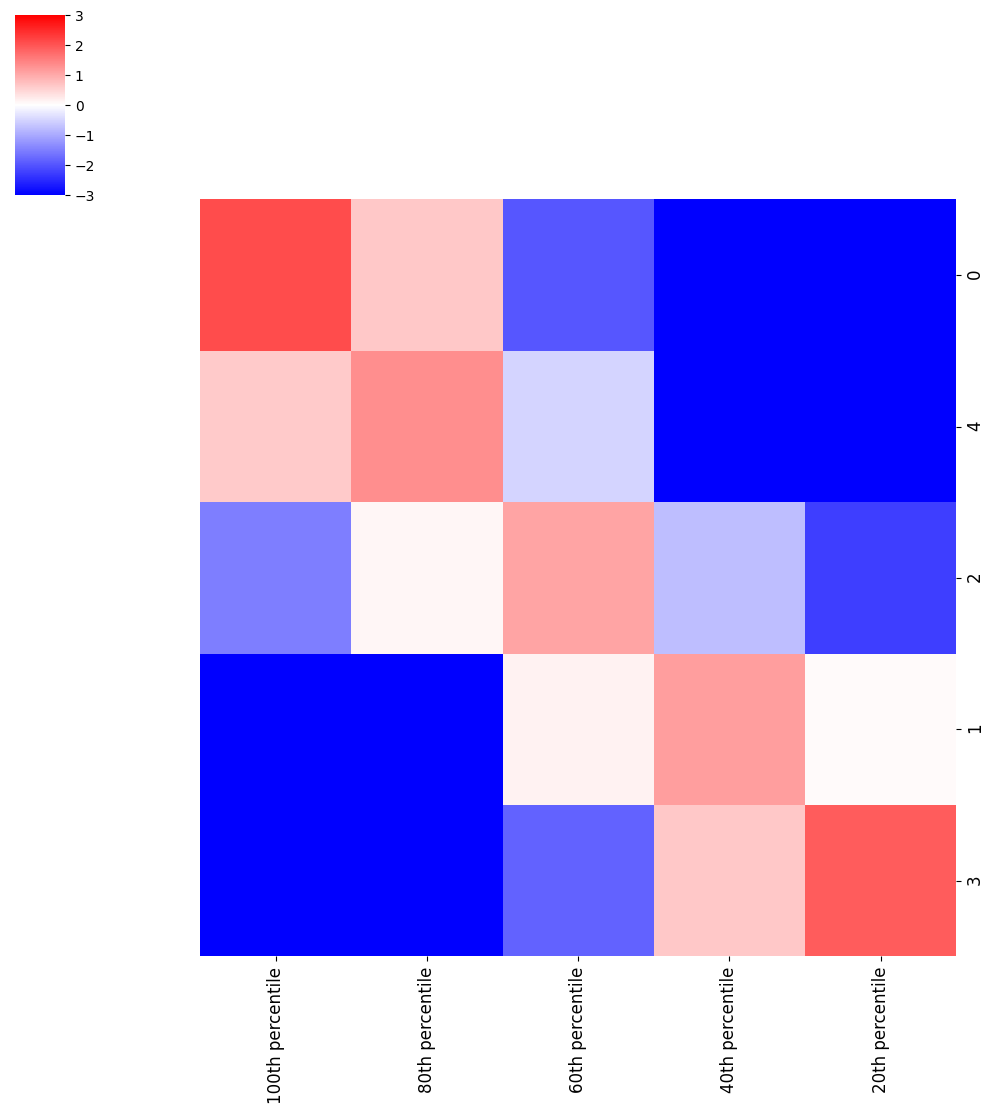

In [23]:
# ---------- compute tissue averages and fold-change ----------
values_sub = df_sub[sum_cols2].values
tissue_avgs = values_sub.mean(axis=0)  # shape (n_celltypes,)

eps = 1e-12
tissue_row = tissue_avgs.reshape(1, -1)
niche_plus = k_centroids[k] + tissue_row
row_sums = niche_plus.sum(axis=1, keepdims=True)
norm = niche_plus / (row_sums + eps)
fc_array = np.log2((norm + eps) / (tissue_row + eps))
fc = pd.DataFrame(fc_array, columns=sum_cols2)

# --------------------------
# New ordering logic: sort columns by percentile extracted from label (descending)
# If columns are categorical with ordered categories, respect that ordering.
# --------------------------

def extract_percentile_number(lbl):
    """
    Try to extract a meaningful integer percentile from a label string.
    Examples handled:
      - "20th percentile" -> 20
      - "P20" or "p20" -> 20
      - "20" -> 20
      - "Bin_3" or "bin 3" -> 3 (lower precedence)
    If no integer is found, returns None.
    """
    s = str(lbl)
    # primary: look for a clear percentile number (e.g., "20th", "20%")
    m = re.search(r'(\d{1,3})\s*(?:th|st|nd|rd)?\s*(?:%|\bpercentile\b)?', s, flags=re.IGNORECASE)
    if m:
        try:
            return int(m.group(1))
        except:
            pass
    # fallback: look for trailing number or Bin_x pattern
    m2 = re.search(r'bin[_\s]*(\d+)', s, flags=re.IGNORECASE)
    if m2:
        try:
            return int(m2.group(1))
        except:
            pass
    m3 = re.search(r'(\d+)$', s)
    if m3:
        try:
            return int(m3.group(1))
        except:
            pass
    return None

# Determine desired column order
# If fc.columns correspond to a categorical with ordered categories in the original df, try to use that
desired_col_order = None

# If original cluster_col in df is categorical and ordered, use that
if pd.api.types.is_categorical_dtype(df[cluster_col]):
    cat_cats = list(df[cluster_col].cat.categories)
    # Use only categories that overlap fc.columns, and preserve order
    desired_col_order = [c for c in cat_cats if c in fc.columns]

# If we didn't obtain an order from categorical metadata, parse numeric percentiles
if not desired_col_order:
    # build list of (col, pct_value) where pct_value may be None
    parsed = [(c, extract_percentile_number(c)) for c in fc.columns]
    # columns with numeric extraction come first, sorted descending by number
    nums = [c for c, v in parsed if v is not None]
    nums_sorted = sorted(nums, key=lambda c: extract_percentile_number(c), reverse=True)
    # non-parsable columns go to the end in original order
    non_nums = [c for c, v in parsed if v is None]
    desired_col_order = nums_sorted + non_nums

# Fallback if nothing matched (shouldn't happen)
if len(desired_col_order) == 0:
    desired_col_order = list(fc.columns)

# reindex fc columns accordingly
fc = fc.reindex(columns=desired_col_order)

# decide the high_bin (left-most column) for ordering rows
high_bin = desired_col_order[0]

# compute row ordering by descending enrichment in the chosen high_bin
ordered_rows = fc[high_bin].sort_values(ascending=False).index.tolist()
fc = fc.reindex(index=ordered_rows)

# --------------------------
# Deterministic ordering using a weighted score on normalized cluster centroids
# Updated to support percentile-style labels (e.g., "20th percentile", "100th percentile")
# --------------------------

import re
import numpy as np
import pandas as pd

# 0) centroids: ensure niche_clusters and sum_cols2 exist
niche_clusters = k_centroids[k]
cent_df = pd.DataFrame(niche_clusters, columns=sum_cols2)  # raw centroids, index = cluster id (0..n-1)

# normalize rows to sum=1 if not already normalized
cent_norm = cent_df.div(cent_df.sum(axis=1) + 1e-12, axis=0)

# Helper: extract integer percentile (or fallback integer) from label, else None
def extract_pct_int(label):
    s = str(label)
    # try phrases like "20th percentile", "20%", "100th", "P20"
    m = re.search(r'(\d{1,3})\s*(?:th|st|nd|rd)?\s*(?:%|\s*percentile\b)?', s, flags=re.IGNORECASE)
    if m:
        try:
            return int(m.group(1))
        except:
            pass
    # fallback: Bin_#
    m2 = re.search(r'bin[_\s]*(\d+)', s, flags=re.IGNORECASE)
    if m2:
        try:
            return int(m2.group(1))
        except:
            pass
    # final fallback: trailing integer
    m3 = re.search(r'(\d+)$', s)
    if m3:
        try:
            return int(m3.group(1))
        except:
            pass
    return None

# 1) Determine desired column order from cent_norm.columns (which should equal sum_cols2)
parsed = [(c, extract_pct_int(c)) for c in cent_norm.columns]

# columns with parsed integer percentiles, sorted descending (so 100 -> 80 -> ...)
cols_with_nums = [c for c, v in parsed if v is not None]
cols_with_nums_sorted = sorted(cols_with_nums, key=lambda c: extract_pct_int(c), reverse=True)

# columns without parsed numbers preserve original relative order and are appended at end
cols_without_nums = [c for c, v in parsed if v is None]

desired_col_order = cols_with_nums_sorted + cols_without_nums

# safety: ensure only existing columns and keep unique
desired_col_order = [c for i, c in enumerate(desired_col_order) if c in cent_norm.columns and c not in desired_col_order[:i]]

# 2) Define exponentially decreasing weights so left-most / highest percentile dominates
base = 2.0
n_cols = len(desired_col_order)
if n_cols == 0:
    raise ValueError("No columns found in centroids to score. Check sum_cols2 / centroids.")
weights = {col: base ** (n_cols - 1 - i) for i, col in enumerate(desired_col_order)}
weight_vector = np.array([weights[c] for c in desired_col_order], dtype=float)

# 3) Compute weighted score for each cluster centroid (rows align with cent_norm.index)
#    Use only the columns in desired_col_order (cent_norm columns already match).
score_vec = cent_norm[desired_col_order].values.dot(weight_vector)

# 4) Build ordering DataFrame for lexicographic tie-break (score descending, then centroid values)
order_df = pd.DataFrame(index=cent_norm.index)
order_df["score"] = score_vec

# append negative centroid values so that larger centroid values sort earlier (descending)
for c in desired_col_order:
    order_df[f"cent_{c}"] = -cent_norm[c].values

# stable sort by score then lexicographic centroid columns
sort_cols = ["score"] + [f"cent_{c}" for c in desired_col_order]
order_df = order_df.sort_values(by=sort_cols, ascending=[False] * len(sort_cols), kind="mergesort")

ordered_rows = order_df.index.tolist()  # cluster row indices ordered by weighted score (descending)

# 5) Reindex fc using this ordering for rows and ensure columns follow desired_col_order
#    If fc doesn't contain all desired_col_order columns (unlikely), keep fc's columns plus missing ones at end
cols_to_use = [c for c in desired_col_order if c in fc.columns]
remaining_fc_cols = [c for c in fc.columns if c not in cols_to_use]
final_cols = cols_to_use + remaining_fc_cols

# Reindex fc (rows = ordered cluster ids, columns = final_cols)
fc = fc.reindex(index=ordered_rows, columns=final_cols)

# 6) Ensure numeric dtype and fill NaNs if any
fc = fc.astype(float)
if fc.isnull().any().any():
    fc = fc.fillna(-999.0)

# 7) Plot clustermap (no clustering)
s = sns.clustermap(
    fc,
    vmin=-3,
    vmax=3,
    cmap='bwr',
    figsize=(10, 10),
    xticklabels=True,
    yticklabels=[str(i) for i in fc.index],
    row_cluster=False,
    col_cluster=False
)

plt.setp(s.ax_heatmap.get_xticklabels(), fontsize=12, rotation=90)
plt.setp(s.ax_heatmap.get_yticklabels(), fontsize=12)
if s.cax is not None:
    s.cax.tick_params(labelsize=10)

# 8) Prepare neighborhood list for subsequent spatial plotting: top-N by weighted score
top_n = min(clusters, len(ordered_rows))
neigh_list = ordered_rows[:top_n]

# Print summary for transparency
print("Desired column order (left->right):", final_cols)
print("Top neighborhoods (by weighted score):", neigh_list)
print(neigh_list)
print(top_n)
order_df


In [24]:
n_conversion_20 = {
    0: '0',
    1: '1',
    2: '2',
    3: '3',
    4: '4',
}


df_sub['Probability_Bin_Cluster'] = df_sub[neighborhood_name].map(n_conversion_20)
df_sub


,x,y,unique_region,Neighborhood,cell_type,true_organization,A,B,ratio,log_ratio,...,20th percentile,40th percentile,60th percentile,80th percentile,100th percentile,Cell Type,Community,Tissue Unit,Neighborhood20,Probability_Bin_Cluster
0,850.585467,931.366005,1,B,2,B,0.001648,0.998352,0.001650,-6.406739,...,0,1,0,0,0,2,None,None,1,1
1,451.564956,166.936956,1,A,11,A,0.261973,0.738027,0.354964,-1.035740,...,0,0,1,0,0,11,None,None,2,2
2,248.735975,591.645276,1,B,12,A,0.217534,0.782466,0.278011,-1.280095,...,0,0,1,0,0,12,None,None,2,2
3,584.153406,326.727948,1,B,4,B,0.001530,0.998470,0.001532,-6.481222,...,0,1,0,0,0,4,None,None,1,1
4,663.688130,711.389394,1,B,4,B,0.011620,0.988380,0.011756,-4.443352,...,0,1,0,0,0,4,None,None,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3335,239.822385,29.471294,1,A,3,A,0.999924,0.000076,13119.537249,9.481858,...,0,0,0,1,0,3,None,None,4,4
3336,442.628147,727.556213,1,A,7,A,0.997847,0.002153,463.507797,6.138823,...,0,0,0,1,0,7,None,None,2,2
3337,440.154406,240.954546,1,B,1,A,0.079657,0.920343,0.086552,-2.447015,...,0,0,1,0,0,1,None,None,2,2
3338,3.745708,397.898635,1,A,10,A,0.999943,0.000057,17512.709307,9.770682,...,0,0,0,1,0,10,None,None,0,0


Prepare stable color and label mappings used across the remaining manuscript panels.


In [25]:
loaded_palette_hex = {0: '#e41a1c',
 1: '#377eb8',
 2: '#4daf4a',
 3: '#984ea3',
 4: '#ff7f00',
 5: '#ffff33',
 6: '#a65628',
 7: '#f781bf',
 8: '#999999',
 9: '#e41a1c'}

## 16. Add coordinates back to the probability table

Merge the original spatial metadata needed for region-level plotting.


In [26]:
df_probabilities['unique_region'] = cells.obs['unique_region']
df_probabilities['x'] = cells.obs['x']
df_probabilities['y'] = cells.obs['y']

In [27]:
df = df_probabilities
total_df= df_sub

## 17. Plot cell-type distributions across the gradient

Use the gradient bins to summarize how cell-type abundance shifts along the Inner-to-Outer follicle axis.

Figure 4c


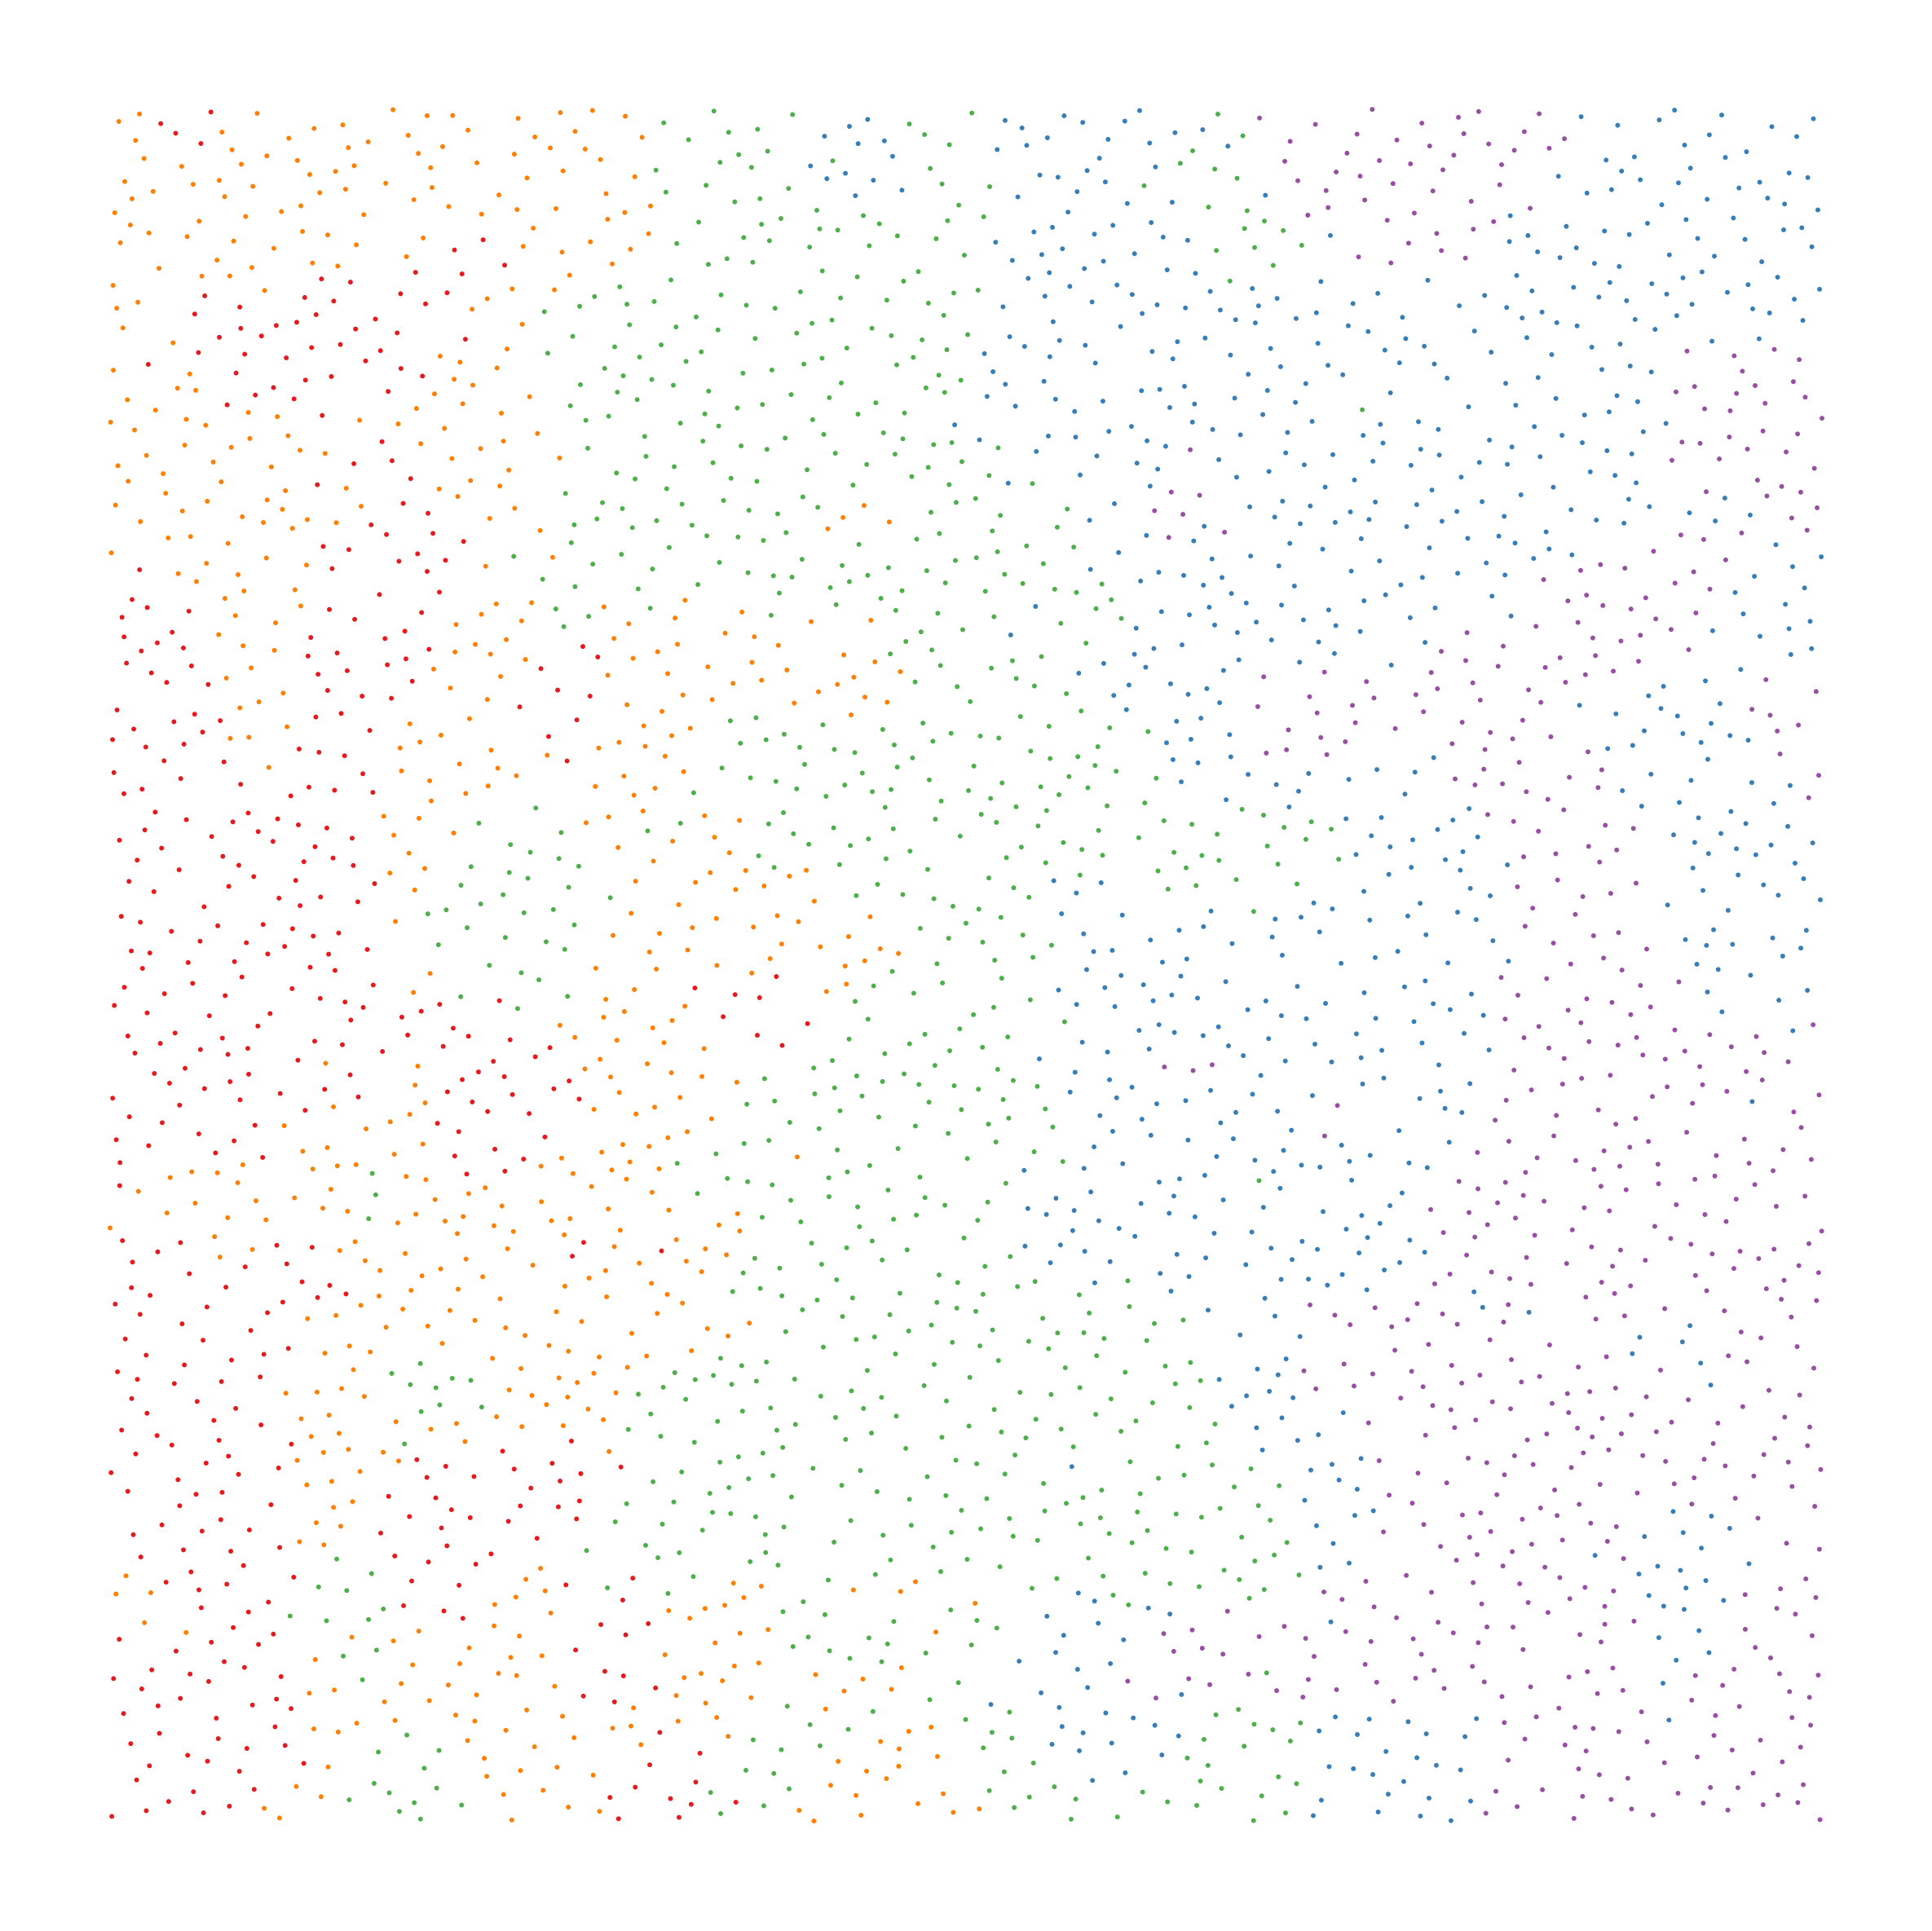

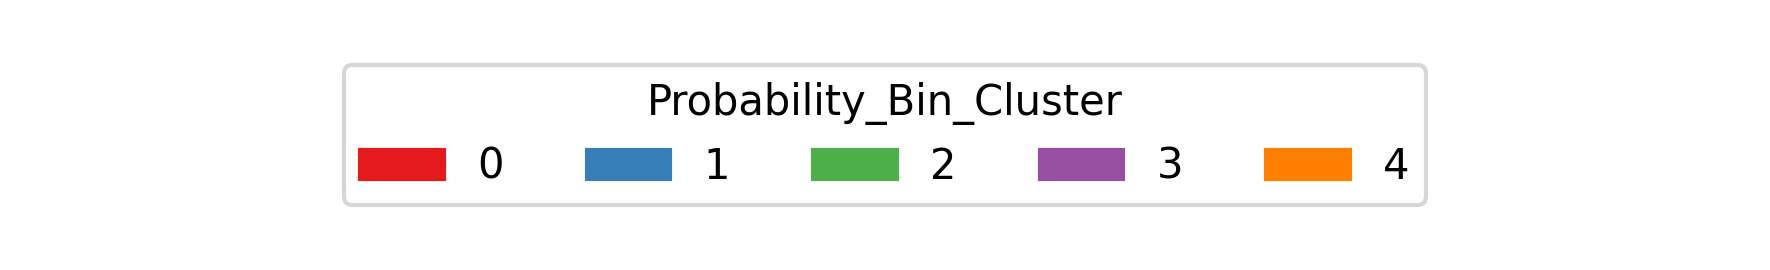

Region plotted: 1
Background cells from df: 0
Colored cells from total_df: 3340


In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# ---------------- User settings ----------------
target_region = '1'
neigh_inner = 'A'
neigh_outer = 'B'

cluster_col_total = 'Probability_Bin_Cluster'   # exists ONLY in total_df
palette = loaded_palette_hex                    # your palette list

dpi_val = 300
marker_size_bg = 2
marker_size_high = 2      # slightly larger but can change
alpha_bg = 0.5
alpha_high = 1

bg_color = 'lightgray'     # background df points
round_dec = 4              # for coordinate dedup
# ------------------------------------------------

# Defensive copies
df_all = df_probabilities.copy()
total = df_sub.copy()

# 1) Subset region for df (BACKGROUND)
region_df = df_all[df_all['unique_region'] == target_region].copy()

# 2) Subset region for inner/outer follicle (the colored points)
colored_df = total[
    (total['unique_region'] == target_region) &
    (total['Neighborhood'].isin([neigh_inner, neigh_outer]))
].copy()

# 3) Build cluster color map from total_df clusters only
cluster_vals = sorted(colored_df[cluster_col_total].dropna().unique())
color_map = {cl: palette[i % len(palette)] for i, cl in enumerate(cluster_vals)}

# 4) Deduplicate (remove colored cells from df)
id_cols = ['cell_id', 'cellID', 'CellID', 'unique_cell_id', 'uid', 'id']
id_col = next((c for c in id_cols if c in colored_df.columns and c in region_df.columns), None)

if id_col is not None:
    colored_ids = set(colored_df[id_col].dropna().astype(str))
    mask_colored_in_region = region_df[id_col].astype(str).isin(colored_ids)

elif set(colored_df.index).issubset(set(region_df.index)):
    mask_colored_in_region = region_df.index.isin(colored_df.index)

else:
    # fallback: match by rounded coordinates
    if {'x', 'y'}.issubset(colored_df.columns) and {'x', 'y'}.issubset(region_df.columns):
        colored_xy = set(zip(
            np.round(colored_df['x'].astype(float), round_dec),
            np.round(colored_df['y'].astype(float), round_dec)
        ))
        region_xy = list(zip(
            np.round(region_df['x'].astype(float), round_dec),
            np.round(region_df['y'].astype(float), round_dec)
        ))
        mask_colored_in_region = pd.Series([xy in colored_xy for xy in region_xy], index=region_df.index)
    else:
        mask_colored_in_region = pd.Series(False, index=region_df.index)

background_df = region_df.loc[~mask_colored_in_region].copy()

# 5) Apply colors based on cluster
def cluster_to_color(series):
    return series.map(color_map).fillna(bg_color)

colored_df['plot_color'] = cluster_to_color(colored_df[cluster_col_total])

# 6) PLOT (NO LEGEND, NO OUTLINES)
fig, ax = plt.subplots(figsize=(8, 8), dpi=dpi_val)

# Background gray
if not background_df.empty:
    ax.scatter(
        background_df['x'], background_df['y'],
        c=bg_color,
        s=marker_size_bg,
        alpha=alpha_bg,
        linewidths=0,
        edgecolors='none'
    )

# Colored inner/outer (plotted on top)
ax.scatter(
    colored_df['x'],
    colored_df['y'],
    c=colored_df['plot_color'],
    s=marker_size_high,
    alpha=alpha_high,
    linewidths=0,       # ← NO outlines
    edgecolors='none'   # ← explicitly no edge
)

ax.axis('off')
ax.set_aspect('equal', 'box')

plt.tight_layout()
plt.show()

# 7) (Optional) Separate cluster legend
patches = [Patch(color=color_map[cl], label=str(cl)) for cl in cluster_vals]
fig_leg, ax_leg = plt.subplots(figsize=(6, 0.4 + len(patches)*0.12), dpi=dpi_val)
ax_leg.axis('off')
ax_leg.legend(handles=patches, title='Probability_Bin_Cluster', loc='center', ncol=min(8, len(patches)))
plt.tight_layout()
plt.show()

# Summary
print(f"Region plotted: {target_region}")
print(f"Background cells from df: {len(background_df)}")
print(f"Colored cells from total_df: {len(colored_df)}")


In [29]:
total_df['Neighborhood20'].value_counts()

Neighborhood20
2    827
1    804
4    651
3    599
0    459
Name: count, dtype: int64

In [30]:
pd.crosstab(
    total_df["Probability_Bin_Cluster"],
    total_df["Neighborhood"]
)

Neighborhood,A,B
Probability_Bin_Cluster,,
0,456,3
1,71,733
2,509,318
3,3,596
4,624,27


## 17. Generate graph summaries with `mg.tl.gb`

Run the gradient-bin graph analysis defined in `src/mingl/tl/gb.py`.

Motivation:
`mg.tl.gb` wraps two plotting paths: probability-bin cluster summaries and a local gradient-magnitude visualization, both driven by ordered score information stored in `adata.obs`.

User-adjustable arguments in `gb(...)`:
- `cluster_key`, `score_key`, `neighborhood_key`: which stored columns to use
- `inner_name`, `outer_name`: labels used for the two-group comparison
- `min_cells`: minimum support for plotted clusters
- `region_key`, `region_value`, `x_key`, `y_key`: spatial plotting selectors
- `k_neighbors`: local neighborhood size for gradient estimation
- `normalize_by`: normalization mode for gradient magnitude
- `make_plots`: whether to render figures immediately

Figure 4e, Figure 4g, Figure 4i


c:\Users\k1van\anaconda3\envs\mingle-env\Lib\functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


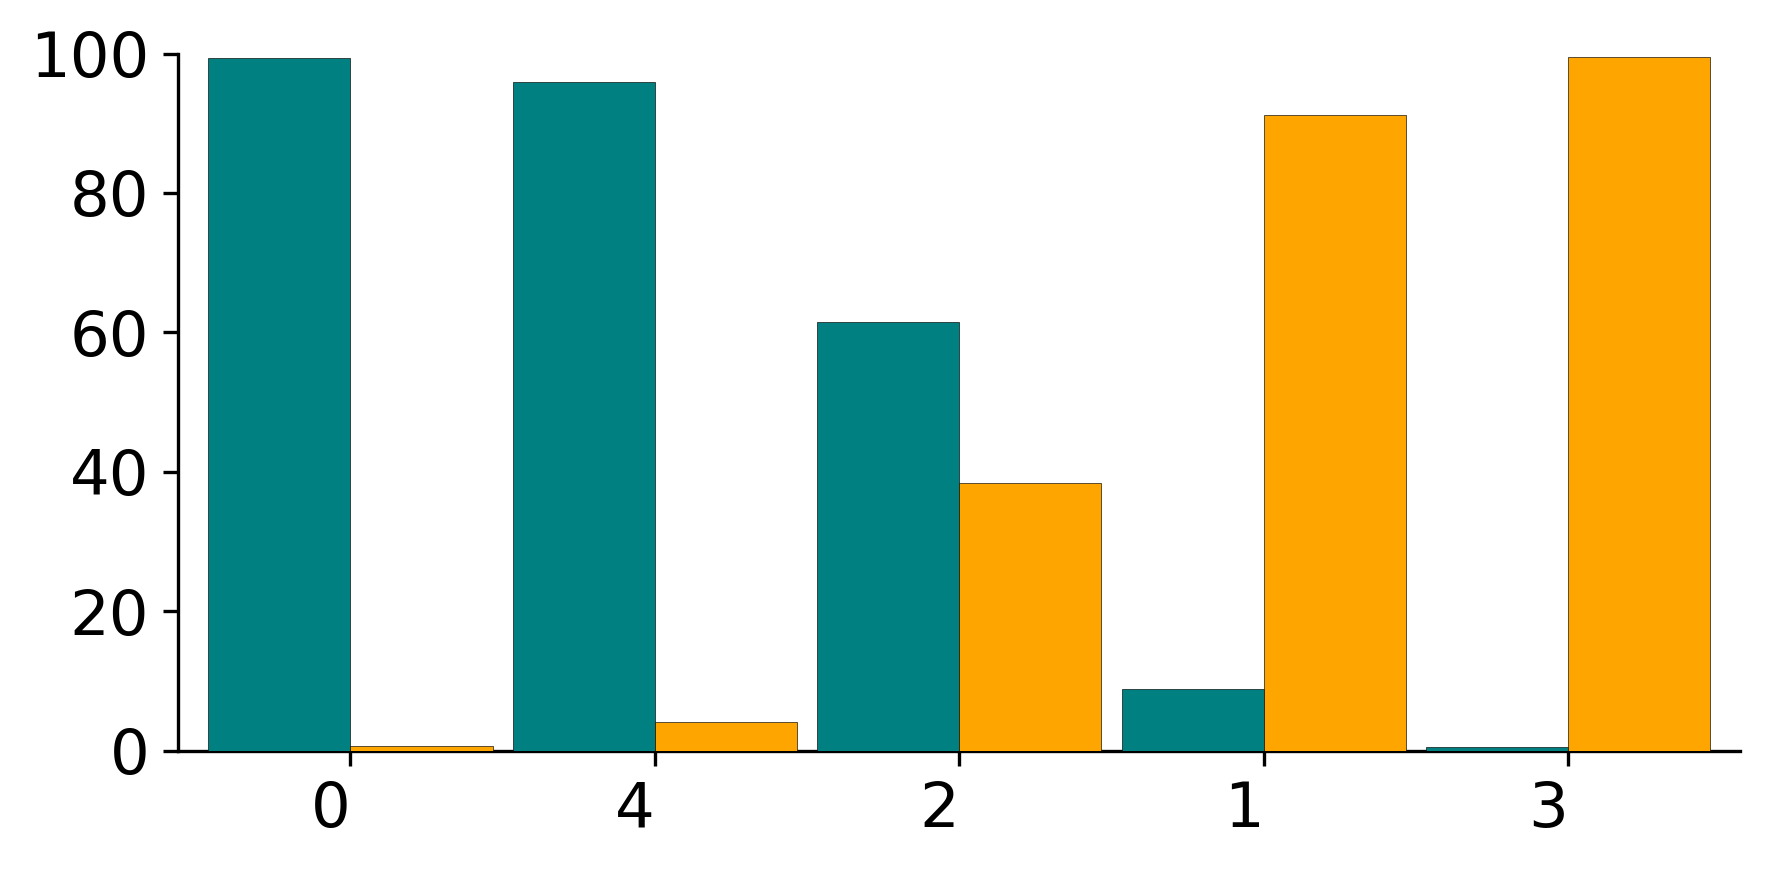

c:\Users\k1van\anaconda3\envs\mingle-env\Lib\site-packages\mingl\tl\gb.py:307: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


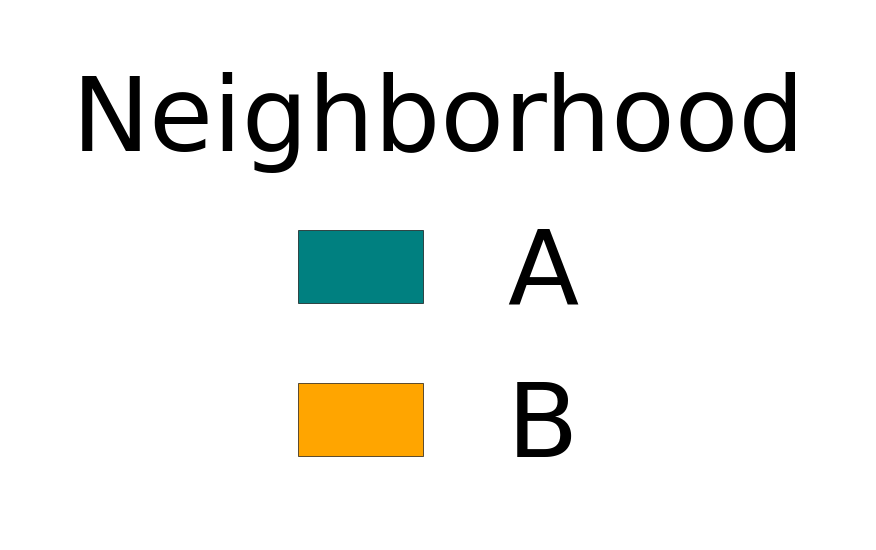

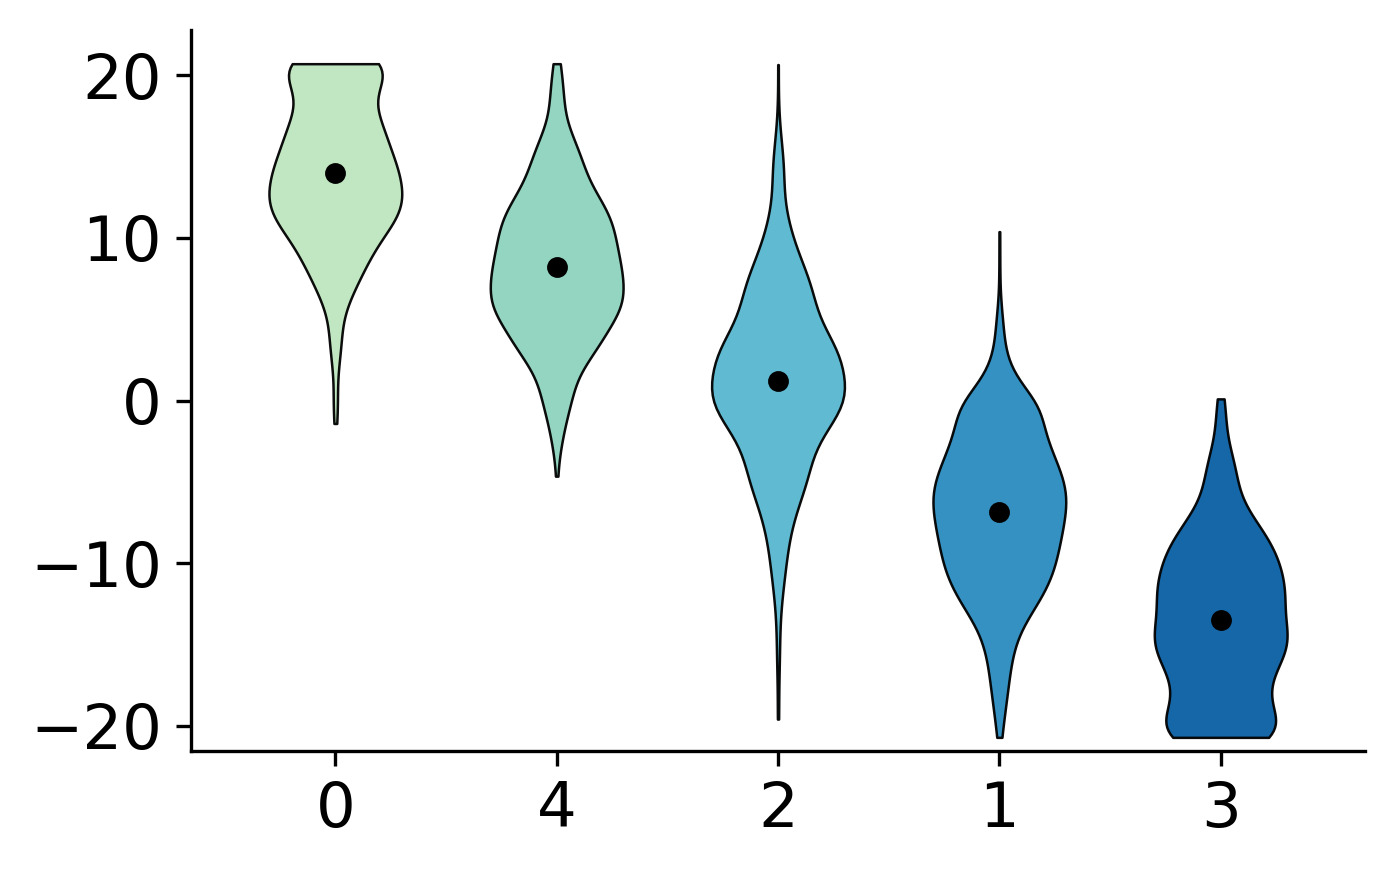

Local gradients (1): 100%|██████████| 3340/3340 [00:00<00:00, 4280.61pt/s]


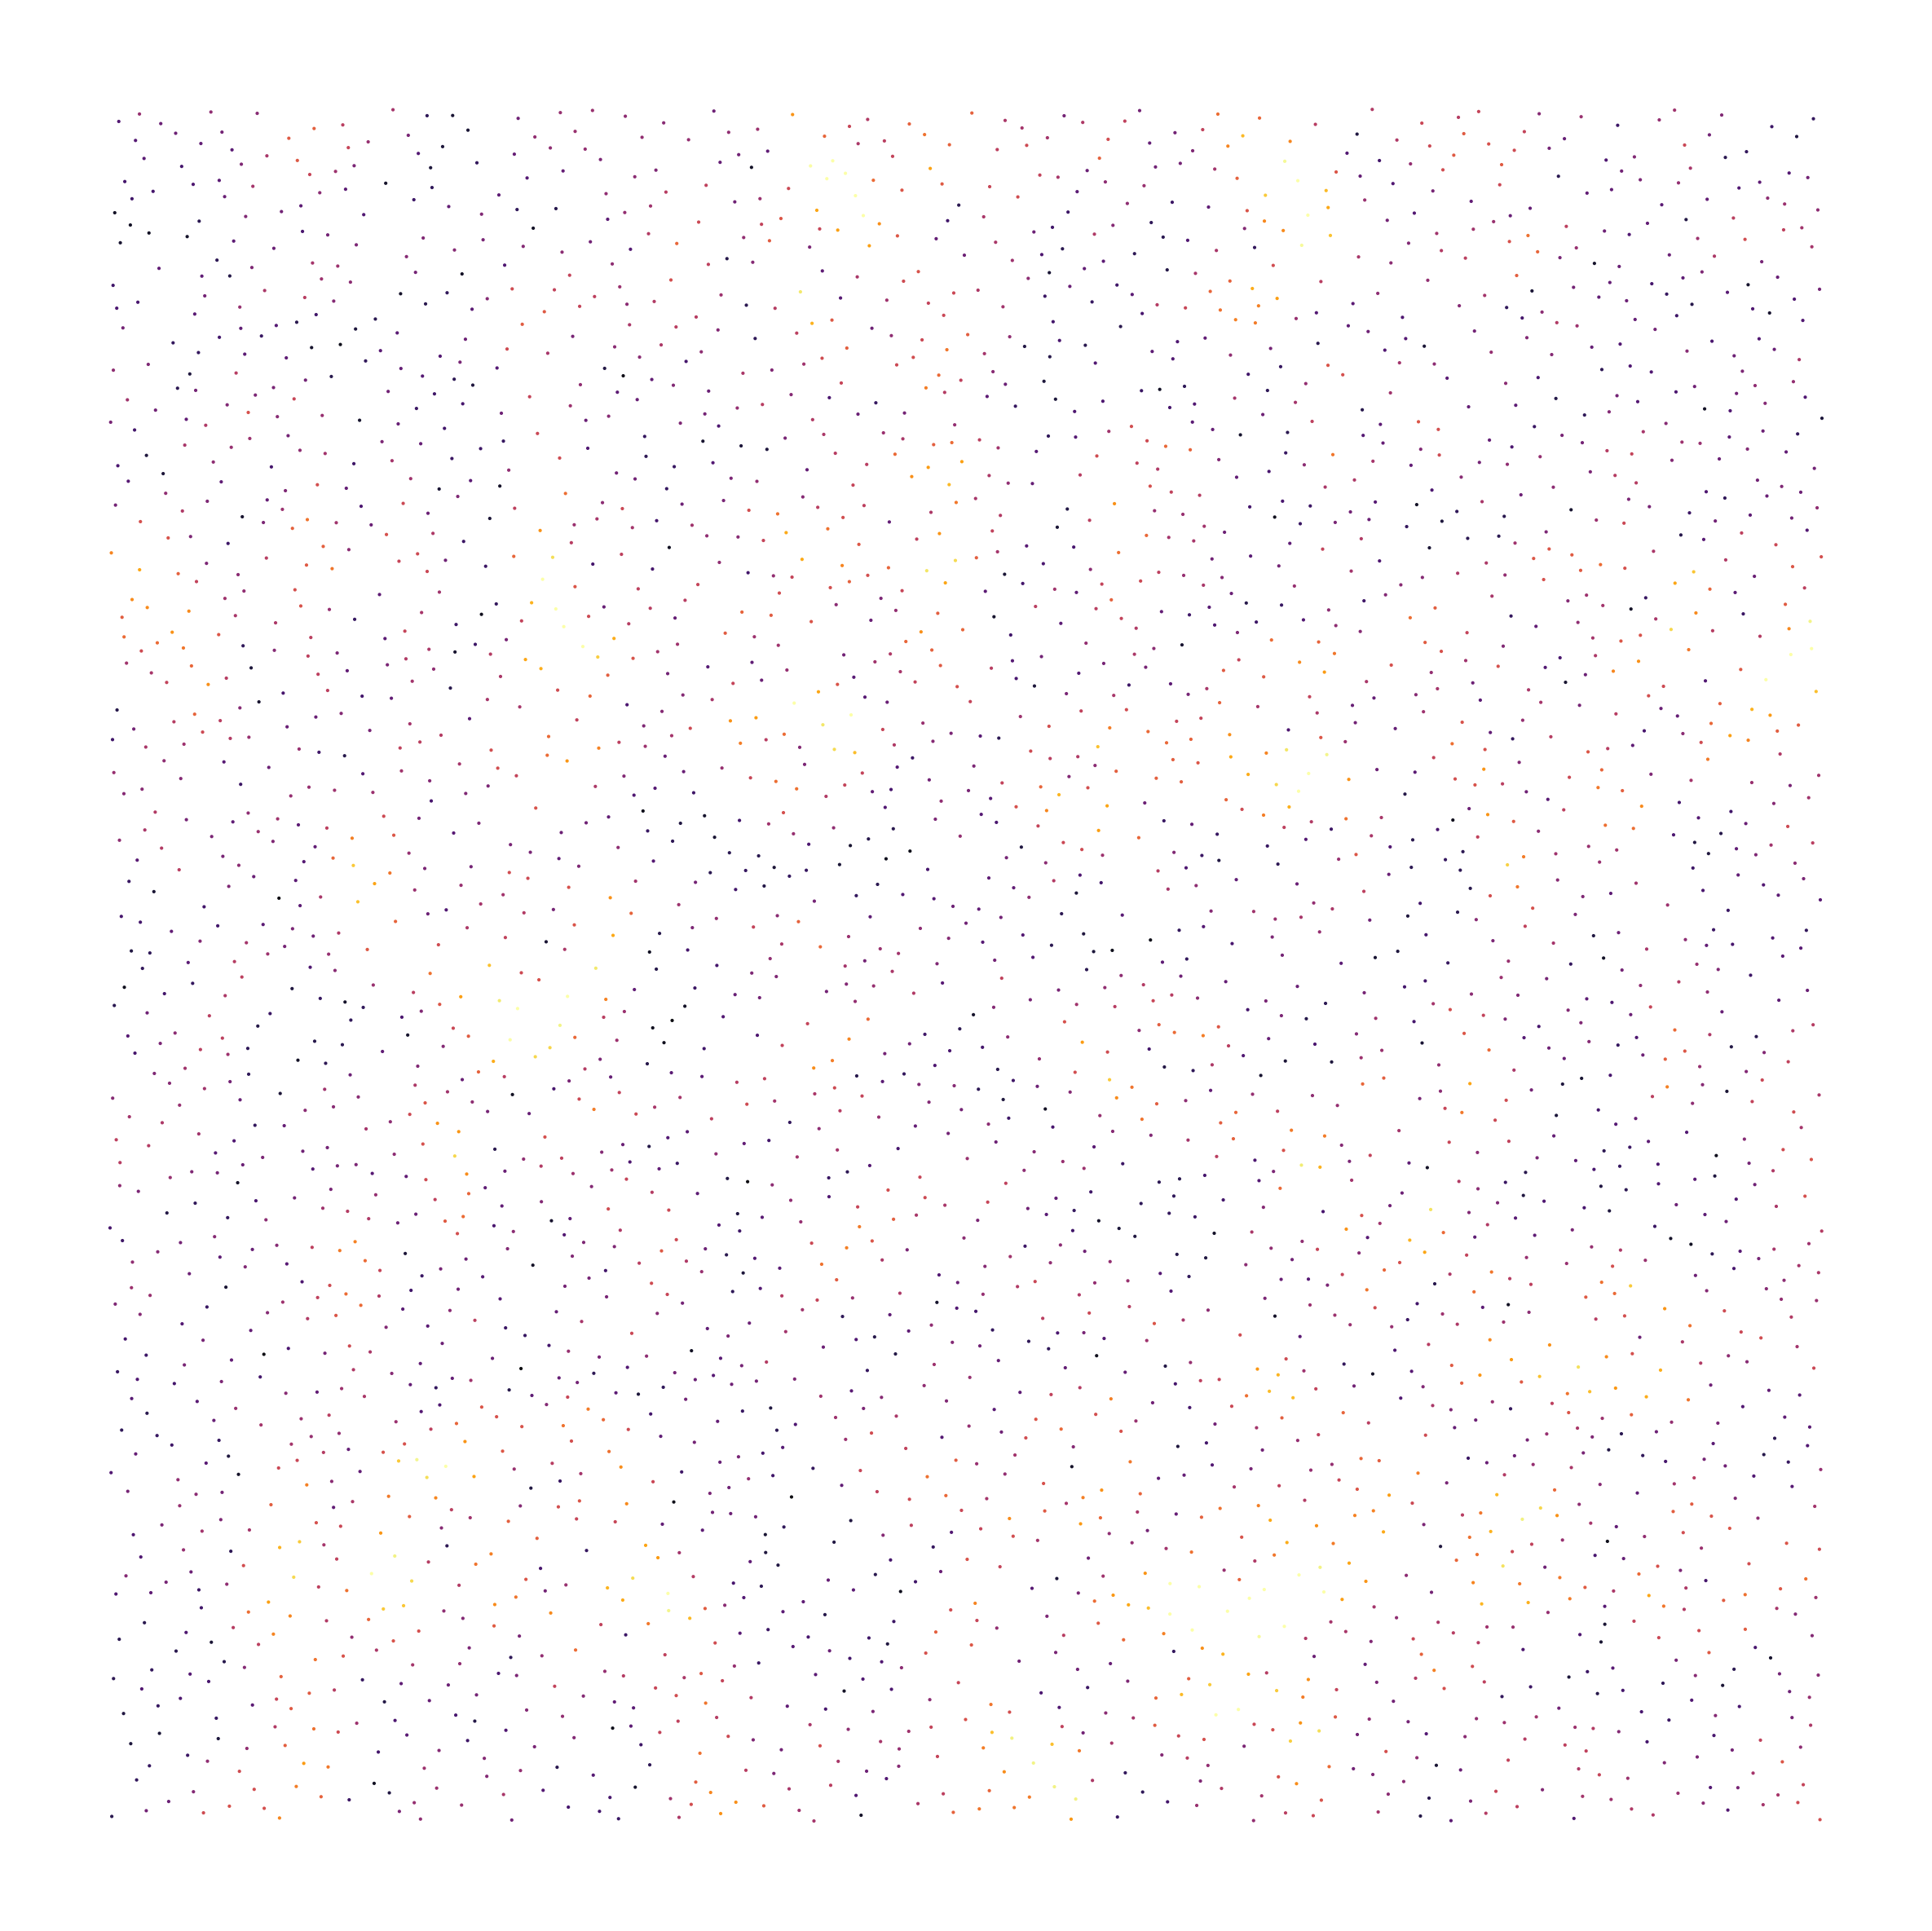

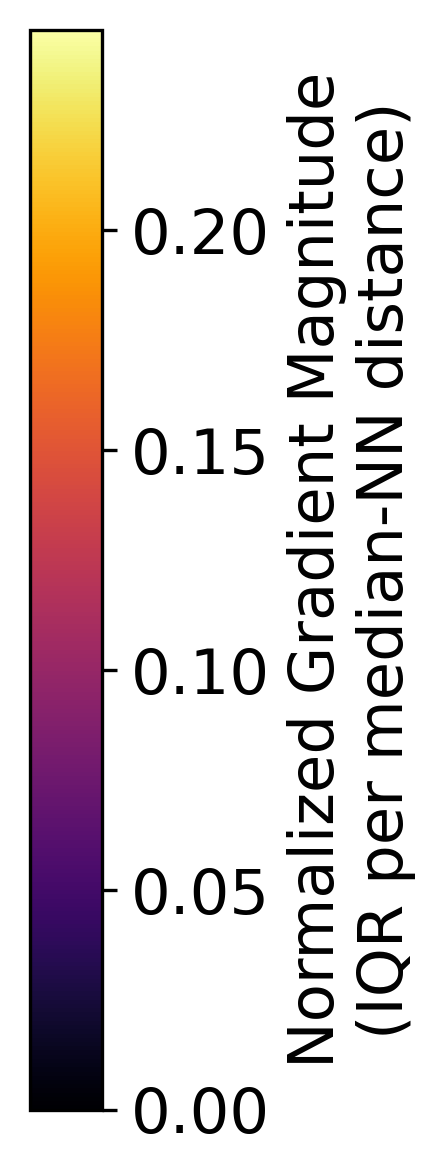

  cluster  inner_pct  outer_pct  total
0       0  99.346405   0.653595    459
1       4  95.852535   4.147465    651
2       2  61.547763  38.452237    827
3       1   8.830846  91.169154    804
4       3   0.500835  99.499165    599
Summary: {'region_key': 'unique_region', 'region_value': '1', 'n_points_used': 3340, 'n_valid_grad': 3340, 'd_med': 12.362131930123468, 'score_iqr': 16.469500626069358, 'score_range': 41.446531675374004, 'normalize_by': 'iqr', 'median_grad_mag_norm': 0.09057196887157333, 'mean_grad_mag_norm': 0.09617796420533585}


In [31]:
import anndata as ad
import mingl as mg
import pandas as pd

# Build AnnData from the existing dataframe used in this section
df_for_gb = total_df.copy()

cluster_key_gb = 'Probability_Bin_Cluster'
if cluster_key_gb not in df_for_gb.columns:
    raise KeyError(
        f"Missing '{cluster_key_gb}' in total_df."
    )

required_cols = ['Score', 'Neighborhood', 'unique_region', 'x', 'y']
missing = [c for c in required_cols if c not in df_for_gb.columns]
if missing:
    raise KeyError(f"Missing required columns for mg.tl.gb: {missing}")

adata_gb = ad.AnnData(obs=df_for_gb.copy())
adata_gb.obs_names = adata_gb.obs.index.astype(str)

region_value_gb = '1'

out = mg.tl.gb(
    adata_gb,
    cluster_key=cluster_key_gb,
    score_key='Score',
    neighborhood_key='Neighborhood',
    inner_name='A',
    outer_name='B',
    min_cells=0,
    pb_prefix='pb',
    region_key='unique_region',
    region_value=region_value_gb,
    x_key='x',
    y_key='y',
    k_neighbors=20,
    normalize_by='iqr',
    grad_prefix='grad',
    make_plots=True,
)

if 'pb_agg_df' in adata_gb.uns:
    print(adata_gb.uns['pb_agg_df'])
if 'grad_summary' in adata_gb.uns:
    print('Summary:', adata_gb.uns['grad_summary'])


## 18. Combine stacked distributions across bins

Figure 4f. Summarize how cell-type abundance shifts along the Inner to Outer Follicle axis. The clusters will automatically arrange in order of increasing probability ratio score enrichment.


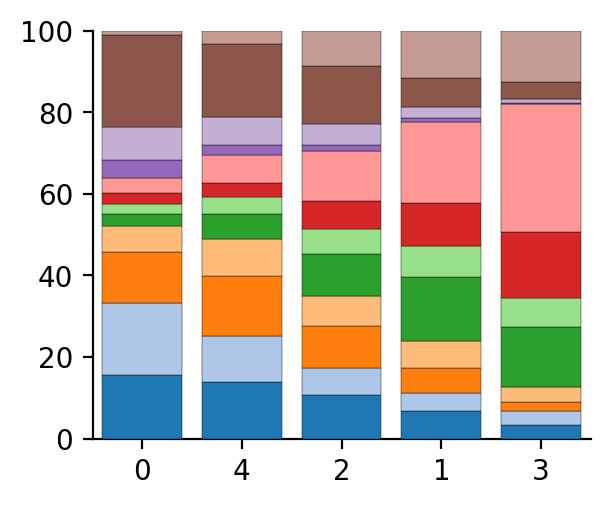

  cluster  weighted_prop  total
0       0      14.588235    459
1       4      10.414747    651
2       2       5.518742    827
3       1       2.337065    804
4       3       1.315526    599


In [32]:
import anndata as ad
import mingl as mg

adata_for_pl = adata_gb.copy()

if 'Probability_Bin_Cluster' not in adata_for_pl.obs.columns:
    raise KeyError("Missing 'Probability_Bin_Cluster' in adata_for_pl.obs.")

fig, ax, rank_df, combined_perc = mg.pl.cell_type_distributions(
    adata_for_pl,
    neighborhoods_to_plot=("A", "B"),
    min_cells=0,
    cluster_key="Probability_Bin_Cluster",
    score_key="Score",
    cell_type_key="Cell Type",
    neighborhood_key="Neighborhood",
    store_key="inner_outer_combined_stacked",
    return_fig=True,
)

print(rank_df.head(20))


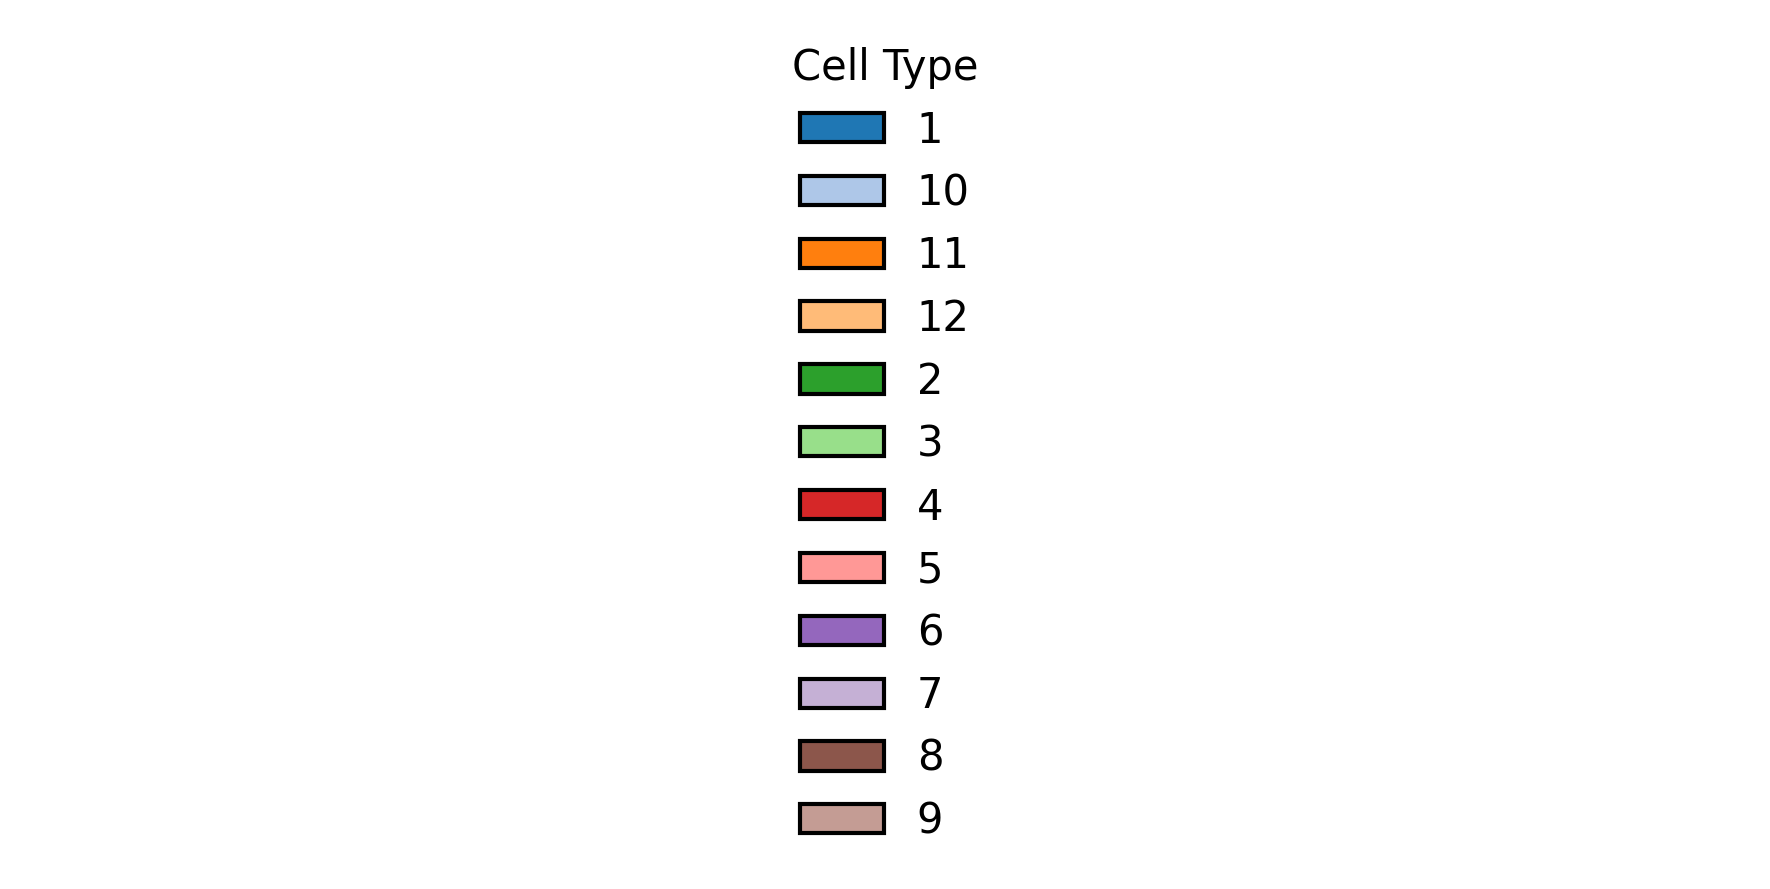

In [33]:
# Legend compatible with mg.pl.cell_type_distributions output/colors
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

store_key = "inner_outer_combined_stacked"
cell_type_key = "cell_type"

# Use exactly the same ordered cell types the plotting function used (if stored)
if store_key in adata_for_pl.uns and "cell_types" in adata_for_pl.uns[store_key]:
    cell_types = list(adata_for_pl.uns[store_key]["cell_types"])
else:
    # Fallback: same ordering logic as mg.pl.cell_type_distributions
    cell_types = sorted(adata_for_pl.obs[cell_type_key].dropna().astype(str).unique())

# Rebuild the same palette sequence used in mg.pl.cell_type_distributions
palette_names = ["tab20", "Set3", "Set2", "Paired", "Dark2", "Accent"]
combined_colors = []
for name in palette_names:
    combined_colors.extend(sns.color_palette(name))

if len(combined_colors) < len(cell_types):
    raise ValueError(f"Not enough distinct colors for {len(cell_types)} cell types.")

color_dict = dict(zip(cell_types, combined_colors[:len(cell_types)]))

# Draw legend-only figure
fig_h = max(2.0, 0.22 * len(cell_types))
fig, ax = plt.subplots(figsize=(6, fig_h), dpi=300)
handles = [mpatches.Patch(facecolor=color_dict[ct], edgecolor="k", label=ct) for ct in cell_types]
ax.legend(handles=handles, loc="center", frameon=False, ncol=1, title="Cell Type")
ax.axis("off")
plt.tight_layout()
plt.show()


## 19. Configure small-multiple cell-type plots

Set up the cell-type-specific summary plots that break the gradient analysis into separate panels.


In [34]:
# ---------------------------
# Setup for small-multiples cell-type subplot (pooled Inner/Outer follicle)
# ---------------------------
import numpy as np
import pandas as pd
import seaborn as sns

total_df_sm = total_df.copy()

required_cols = ['Neighborhood', 'cell_type']
missing_req = [c for c in required_cols if c not in total_df_sm.columns]
if missing_req:
    raise KeyError(f"Missing required columns for small-multiples setup: {missing_req}")

cluster_col_sm = 'Probability_Bin_Cluster'
if cluster_col_sm not in total_df_sm.columns:
    raise KeyError("Missing 'Probability_Bin_Cluster' in total_df.")

total_df_sm = total_df_sm.copy()
total_df_sm['_cluster_str'] = total_df_sm[cluster_col_sm].astype(str).str.strip()

# user parameters aligned to the reference script
neighborhoods_to_plot = ["A", "B"]
min_cells = 0
inner_name = neighborhoods_to_plot[0]
outer_name = neighborhoods_to_plot[1]

# Build ranking order (same weighted_prop idea as the reference script)
canonical_bins = ["Very Low", "Low", "Medium", "High", "Very High"]
weights = {b: 2 ** i for i, b in enumerate(canonical_bins)}

if 'Score' in total_df_sm.columns and pd.api.types.is_numeric_dtype(total_df_sm['Score']):
    try:
        mapped = pd.qcut(total_df_sm['Score'], q=[0, .2, .4, .6, .8, 1.0], labels=canonical_bins, duplicates='drop')
        df_rank_sm = total_df_sm.copy()
        df_rank_sm['_bin_mapped'] = mapped.astype(object)
    except Exception:
        df_rank_sm = total_df_sm.copy()
        v = pd.to_numeric(df_rank_sm['Score'], errors='coerce')
        edges = np.linspace(float(v.min()), float(v.max()), len(canonical_bins) + 1)
        df_rank_sm['_bin_mapped'] = pd.cut(v, bins=np.unique(edges), labels=canonical_bins[:max(1, len(np.unique(edges))-1)], include_lowest=True).astype(object)
else:
    df_rank_sm = total_df_sm.copy()
    df_rank_sm['_bin_mapped'] = "Medium"

cluster_keys = sorted(df_rank_sm['_cluster_str'].dropna().unique(), key=str)
rank_rows = []
for cl in cluster_keys:
    sub = df_rank_sm[df_rank_sm['_cluster_str'] == cl]
    n = len(sub)
    if n == 0:
        continue
    vc = sub['_bin_mapped'].value_counts(dropna=False).to_dict()
    props = {b: vc.get(b, 0) / n for b in canonical_bins}
    weighted_prop = sum(props[b] * weights[b] for b in canonical_bins)
    rank_rows.append({'cluster': cl, 'weighted_prop': weighted_prop, 'total': n})

rank_df_sm = pd.DataFrame(rank_rows).sort_values(['weighted_prop', 'total'], ascending=[False, False]).reset_index(drop=True)
global_cluster_order = rank_df_sm['cluster'].tolist()

# Subset + min_cells filter
inner_subset = total_df_sm[total_df_sm['Neighborhood'].astype(str).str.lower() == inner_name.lower()].copy()
outer_subset = total_df_sm[total_df_sm['Neighborhood'].astype(str).str.lower() == outer_name.lower()].copy()

clusters_ok = []
for cl in global_cluster_order:
    if (inner_subset['_cluster_str'] == cl).sum() >= min_cells and (outer_subset['_cluster_str'] == cl).sum() >= min_cells:
        clusters_ok.append(cl)

if len(clusters_ok) == 0:
    raise ValueError(f"No clusters meet min_cells={min_cells} for both neighborhoods.")

# expose variables expected by the plotting cell
inner_order = clusters_ok
combined_subset = pd.concat([inner_subset, outer_subset], ignore_index=True)

# Build cell type palette consistent with previous cells
cell_type_list = sorted(combined_subset['Cell Type'].dropna().astype(str).unique().tolist())
palette_names = ['tab20', 'Set3', 'Set2', 'Paired', 'Dark2', 'Accent']
combined_colors = []
for name in palette_names:
    combined_colors.extend(sns.color_palette(name))
if len(combined_colors) < len(cell_type_list):
    raise ValueError(f"Not enough colors ({len(combined_colors)}) for {len(cell_type_list)} cell types.")
color_dict = dict(zip(cell_type_list, combined_colors[:len(cell_type_list)]))

print('Prepared variables for small-multiples plot.')
print('Clusters (inner_order):', inner_order)
print('Cell types:', len(cell_type_list))


Prepared variables for small-multiples plot.
Clusters (inner_order): ['0', '4', '2', '1', '3']
Cell types: 12


Create the per-cell-type subplots across the ordered probability bins.

Supplemental Figure 3a.

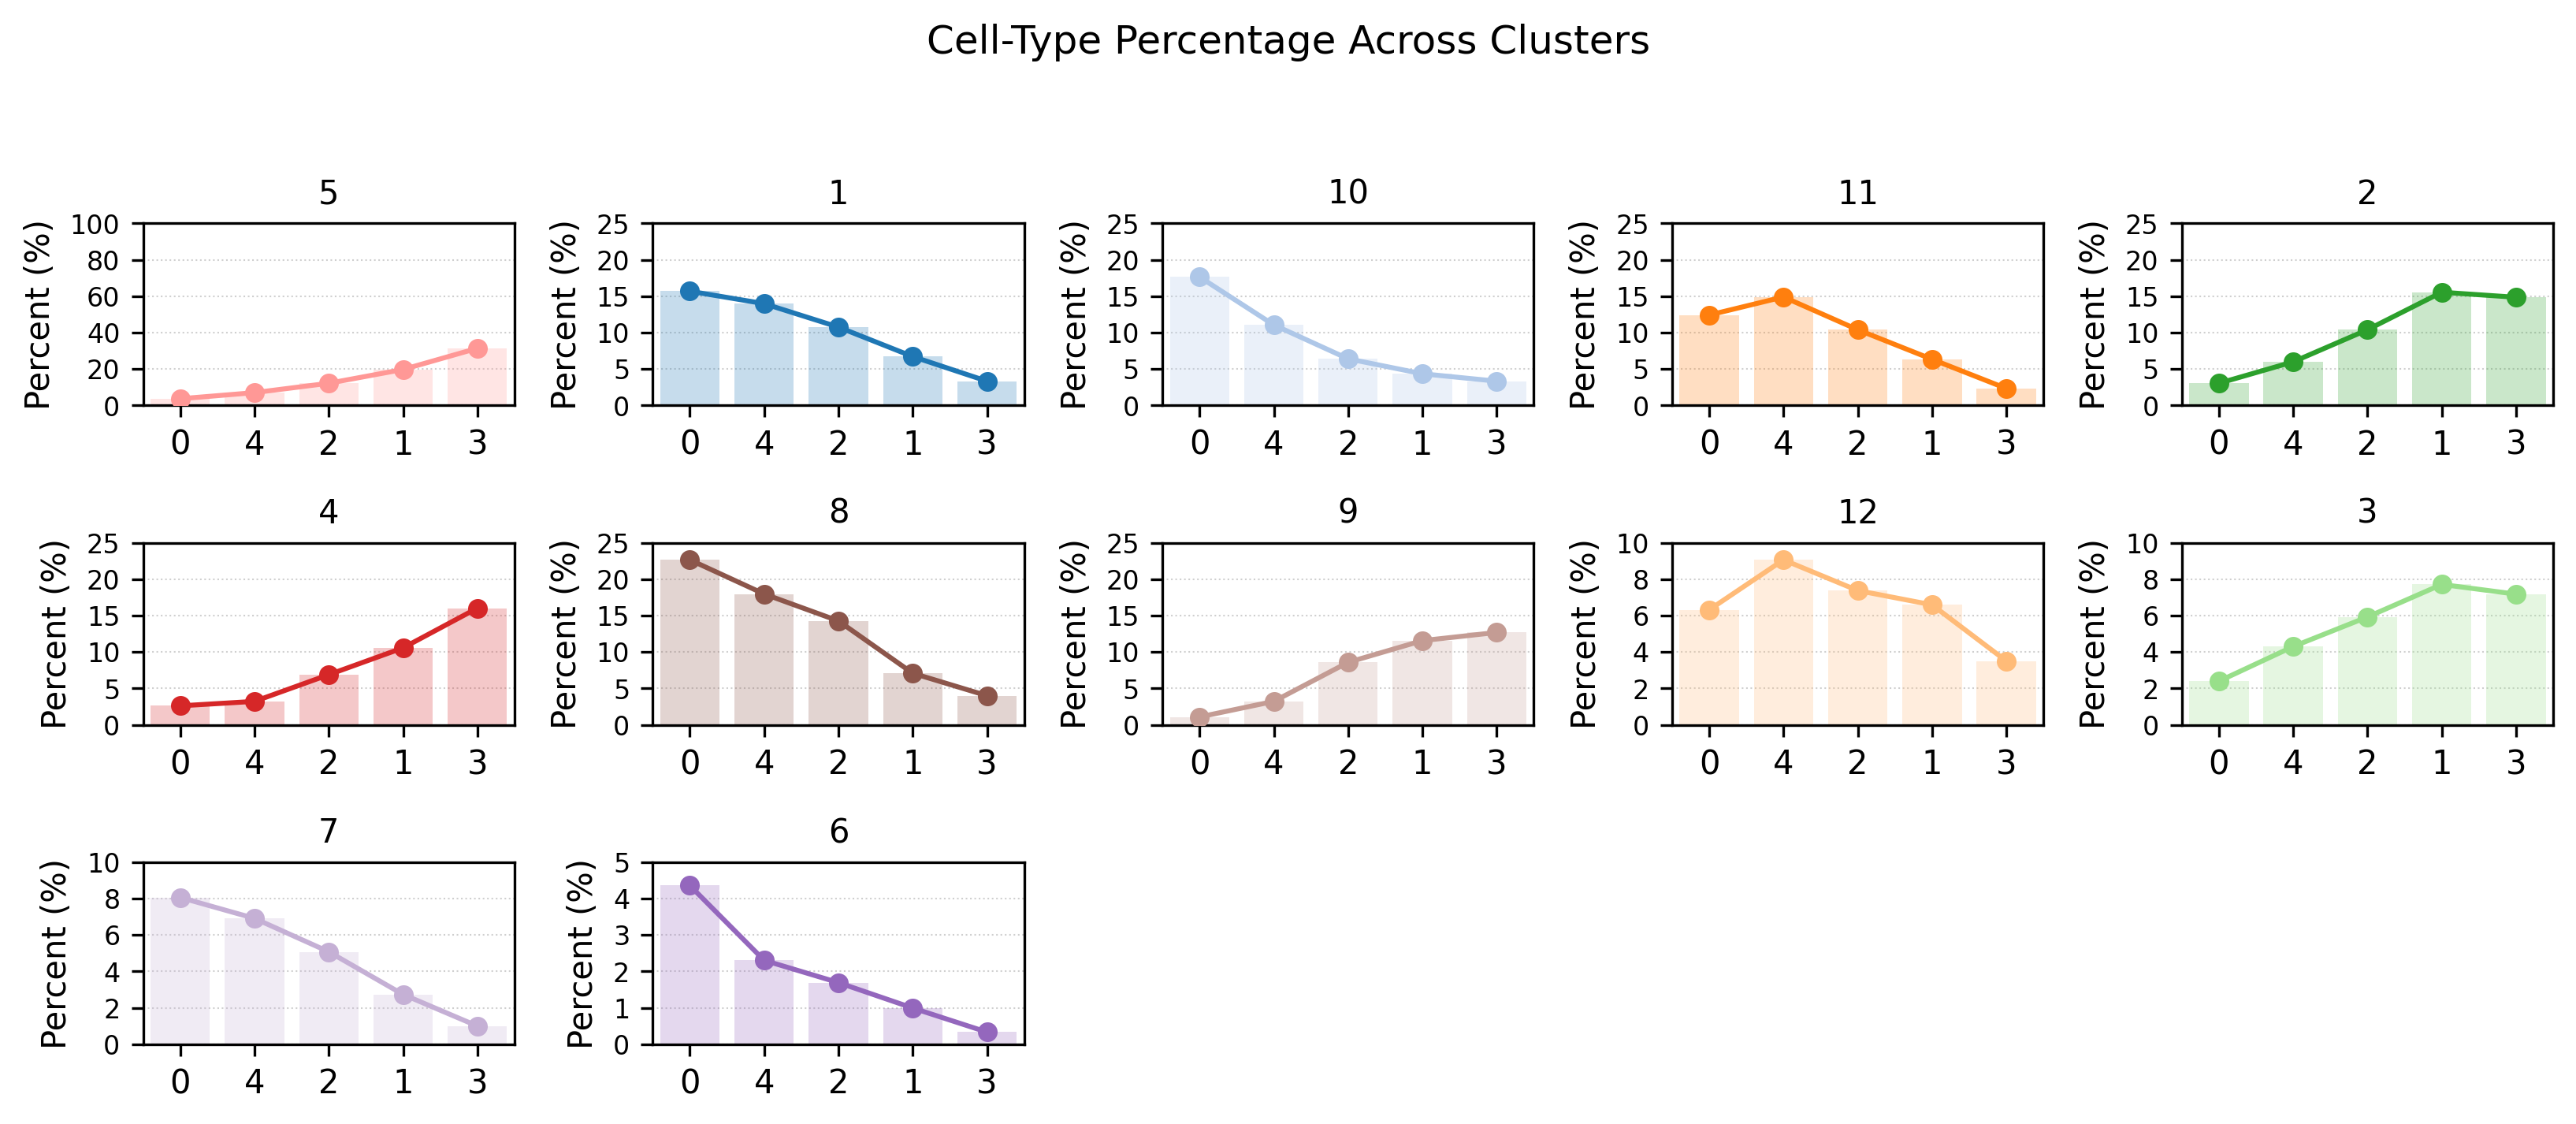

In [35]:
# ---------------------------
# Small-multiples: per-cell-type subplots
# - fixed y-axis choices: 0-1, 0-5, 0-10, 0-25, 0-100
# - subplots ordered by y-range (largest first)
# - show x-tick labels on ALL subplots
# ---------------------------

import math
import matplotlib.pyplot as plt
import numpy as np

cluster_order = inner_order
num_clusters = len(cluster_order)

ct_list = list(cell_type_list)

# ------------------------------------------------
# Helper: compute percent per cluster for each cell type
# ------------------------------------------------
def compute_percent_matrix_combined(full_df_subset, cluster_order, cell_types):
    ct_series = full_df_subset['cell_type'].astype(str)
    perc = {ct: np.zeros(len(cluster_order)) for ct in cell_types}
    for i, cl in enumerate(cluster_order):
        mask = full_df_subset['_cluster_str'] == cl
        total = int(mask.sum())
        for ct in cell_types:
            perc[ct][i] = ((mask) & (ct_series == ct)).sum() / total * 100.0 if total > 0 else 0.0
    return perc

perc_matrix = compute_percent_matrix_combined(combined_subset, cluster_order, ct_list)

# ------------------------------------------------
# Decide y-range per cell type
# ------------------------------------------------
AVAILABLE_RANGES = [1, 5, 10, 25, 100]
TICK_SPACING = {
    1: 0.2,
    5: 1,
    10: 2,
    25: 5,
    100: 20,
}

celltype_meta = []
for ct in ct_list:
    y = perc_matrix[ct]
    observed_max = float(np.nanmax(y)) if len(y) > 0 else 0.0

    chosen_range = None
    for r in AVAILABLE_RANGES:
        if observed_max <= r:
            chosen_range = r
            break

    if chosen_range is None:
        chosen_range = 100

    if observed_max == 0:
        chosen_range = 1

    celltype_meta.append((ct, chosen_range))

# ------------------------------------------------
# ORDER subplots: largest y-range first
# ------------------------------------------------
celltype_meta_sorted = sorted(celltype_meta, key=lambda x: x[1], reverse=True)
ordered_cell_types = [ct for ct, _ in celltype_meta_sorted]
range_lookup = dict(celltype_meta_sorted)

# ------------------------------------------------
# Plotting grid
# ------------------------------------------------
n_celltypes = len(ordered_cell_types)
ncols = min(5, n_celltypes)
nrows = int(math.ceil(n_celltypes / ncols))

fig_w = max(4, 2.2 * ncols)
fig_h = max(2, 1.6 * nrows)

fig, axes = plt.subplots(nrows, ncols, figsize=(fig_w, fig_h), dpi=300, squeeze=False)
axes_flat = axes.flatten()

x = np.arange(num_clusters)
x_labels = [str(c) for c in cluster_order]

for i, ct in enumerate(ordered_cell_types):
    ax = axes_flat[i]
    y = perc_matrix[ct]
    color = color_dict.get(ct, (0.4, 0.4, 0.4))

    chosen_range = range_lookup[ct]

    ax.plot(x, y, marker='o', linewidth=1.5, markersize=5, color=color, zorder=4)
    ax.bar(x, y, alpha=0.25, color=color, edgecolor='none', zorder=2)

    ax.set_ylim(0, chosen_range)
    spacing = TICK_SPACING[chosen_range]
    yticks = np.arange(0, chosen_range + 1e-9, spacing)
    ax.set_yticks(yticks)
    ax.set_yticklabels([f"{t:.1f}" if chosen_range == 1 else f"{int(t)}" for t in yticks], fontsize=8)

    ax.set_title(f"{ct}", fontsize=10, pad=6)
    ax.set_xticks(x)
    ax.set_xticklabels(x_labels, rotation=0, ha='center', fontsize=10)

    ax.set_xlim(-0.5, num_clusters - 0.5)
    ax.grid(axis='y', linestyle=':', linewidth=0.5, alpha=0.6)
    ax.set_ylabel('Percent (%)', fontsize=10)

for j in range(n_celltypes, len(axes_flat)):
    axes_flat[j].axis('off')

plt.suptitle('Cell-Type Percentage Across Clusters', fontsize=12)
plt.tight_layout(rect=[0, 0.0, 1, 0.94])
plt.show()


## 20. Plot global steepness along the gradient

Estimate and visualize global steepness trends across the ordered probability bins.

Output is a steepness score that can be compared across conditions or transitions. A larger transition score means that the transition is more stark.

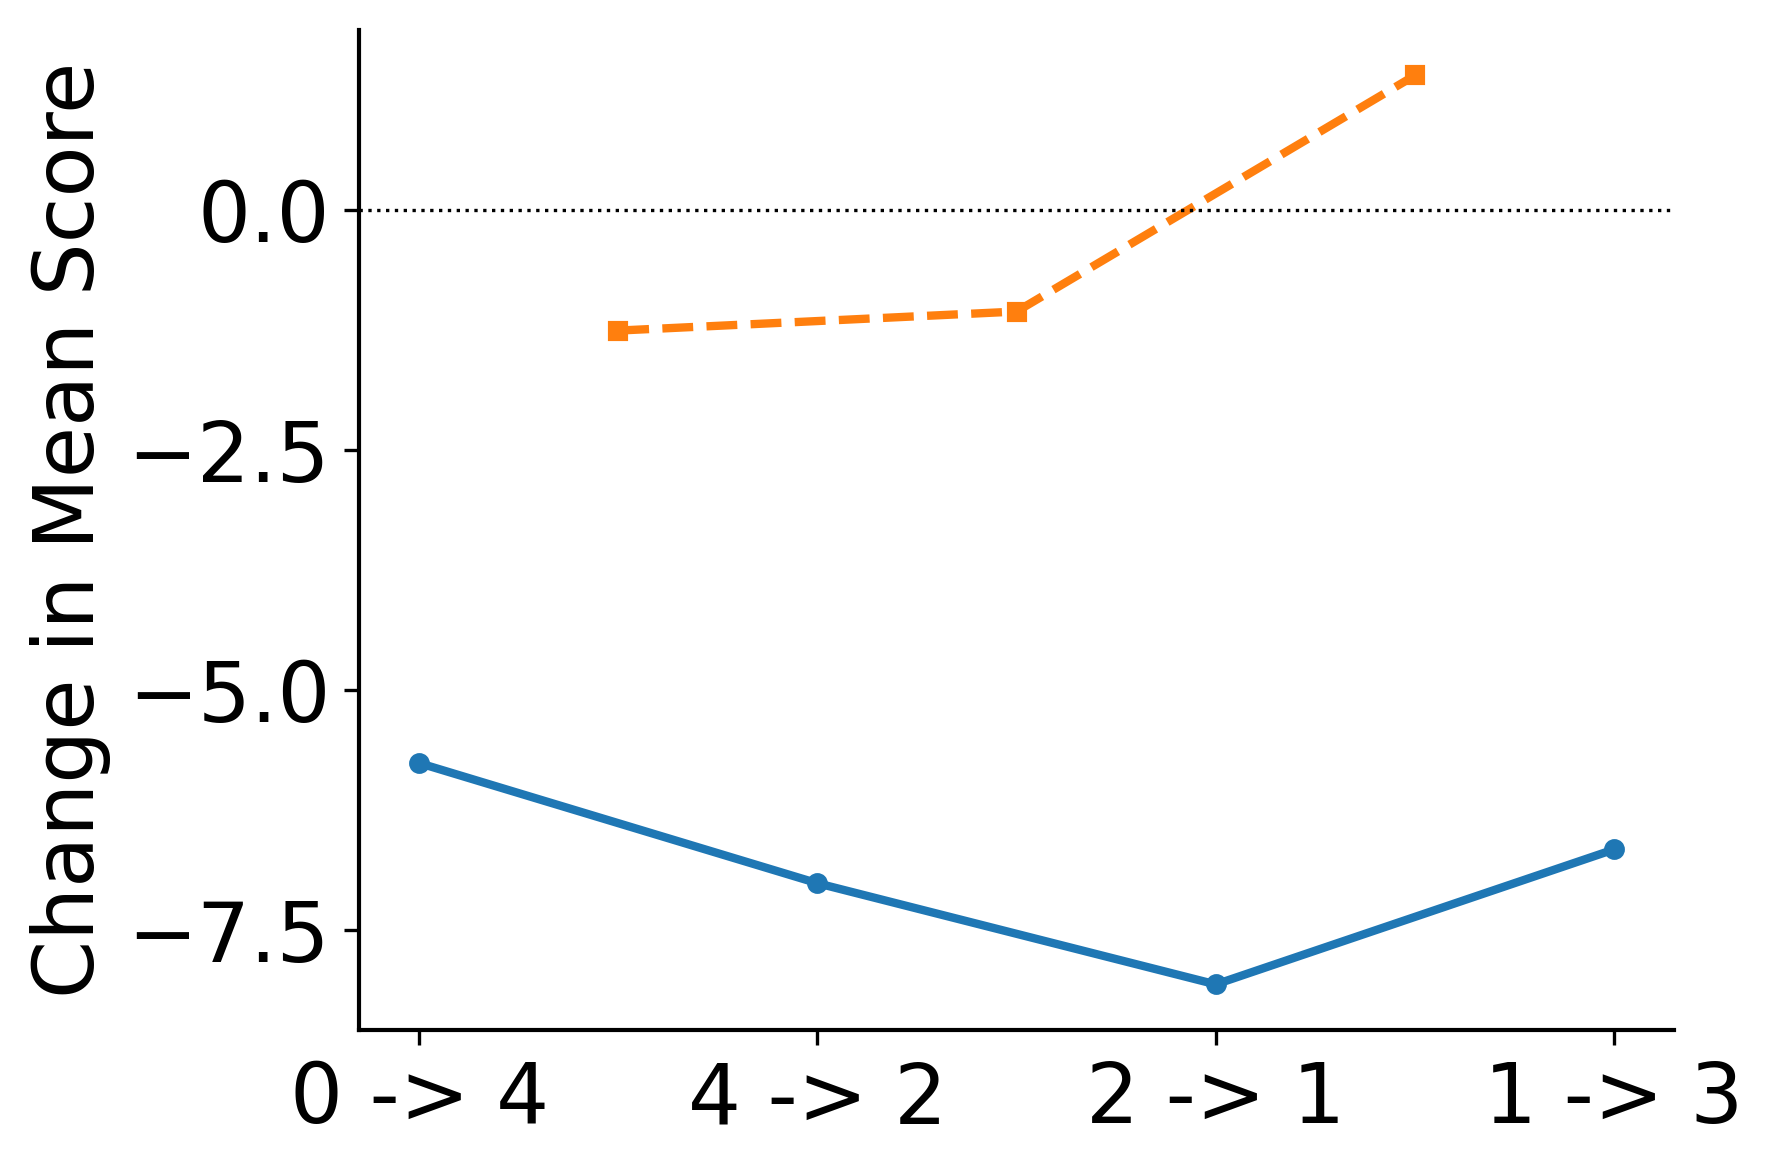

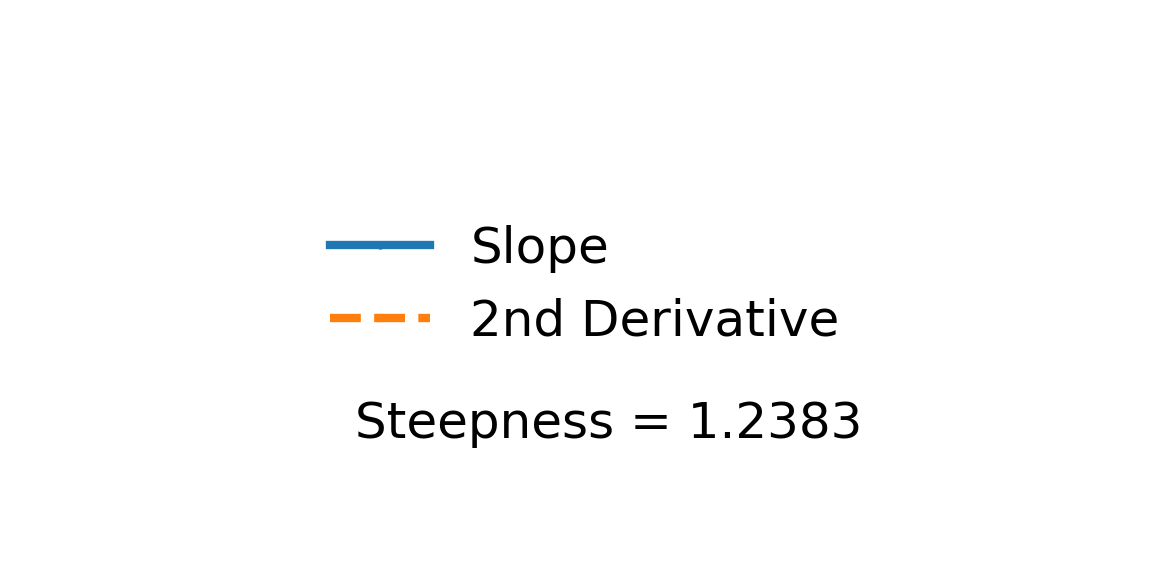

Clusters plotted (order): ['0', '4', '2', '1', '3']
First derivative (Δ mean score): [-5.762906 -7.016043 -8.070657 -6.66354 ]
Second derivative (Δ of Δ): [-1.253137 -1.054615  1.407118]
Global slope = -7.0113
Normalized slope (slope / IQR) = 0.425714 IQR/cluster
Steepness (mean |2nd derivative| / IQR) = 1.23829


In [37]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from sklearn.linear_model import LinearRegression
import pandas as pd

# --------------------------------------------------
# Resolve dataframe/columns in this notebook context
# --------------------------------------------------
df_plot = total_df.copy()

cluster_col = 'Probability_Bin_Cluster'
score_col = 'Score'
n_bins = 5

if cluster_col not in df_plot.columns:
    raise KeyError(f"Missing '{cluster_col}' in dataframe.")

if score_col not in df_plot.columns:
    raise KeyError(f"Missing '{score_col}' in dataframe.")

# --------------------------------------------------
# Fallback cluster ordering helper (used only if needed)
# --------------------------------------------------
def _compute_cluster_order_score_weighted_local(df_in, cluster_col, score_col, n_bins=5):
    canonical_bins = ["Very Low", "Low", "Medium", "High", "Very High"]
    weights = {b: 2**i for i, b in enumerate(canonical_bins)}

    d = df_in.copy()
    d['cluster_str'] = d[cluster_col].astype(str).str.strip()

    s = pd.to_numeric(d[score_col], errors='coerce')
    if s.notna().any():
        try:
            mapped = pd.qcut(s, q=n_bins, labels=canonical_bins, duplicates='drop')
            d['_bin_mapped'] = mapped.astype(object)
        except Exception:
            v = s.dropna()
            if v.empty:
                d['_bin_mapped'] = "Medium"
            else:
                edges = np.linspace(float(v.min()), float(v.max()), n_bins + 1)
                u = np.unique(edges)
                labels_use = canonical_bins[:max(1, len(u) - 1)]
                d['_bin_mapped'] = pd.cut(s, bins=u, labels=labels_use, include_lowest=True).astype(object)
    else:
        d['_bin_mapped'] = "Medium"

    cluster_keys = sorted(d['cluster_str'].dropna().unique(), key=str)
    rows = []
    for cl in cluster_keys:
        sub = d[d['cluster_str'] == cl]
        n = len(sub)
        if n == 0:
            continue
        vc = sub['_bin_mapped'].value_counts(dropna=False).to_dict()
        props = {b: vc.get(b, 0) / n for b in canonical_bins}
        weighted_prop = sum(props[b] * weights[b] for b in canonical_bins)
        rows.append({'cluster': cl, 'weighted_prop': weighted_prop, 'total': n})

    rank_df_local = pd.DataFrame(rows).sort_values(['weighted_prop', 'total'], ascending=[False, False]).reset_index(drop=True)
    return rank_df_local['cluster'].tolist()

# --------------------------------------------------
# Ensure ordered clusters exist
# --------------------------------------------------
ordered_clusters = [str(x) for x in _compute_cluster_order_score_weighted_local(df_plot, cluster_col, score_col, n_bins=n_bins)]

# --------------------------------------------------
# Compute mean score per cluster IN THAT ORDER
# --------------------------------------------------
agg = df_plot.groupby(df_plot[cluster_col].astype(str))[score_col].mean()
clusters_in_plot = [c for c in ordered_clusters if c in agg.index]
means = agg.loc[clusters_in_plot].values.astype(float)

n = len(means)
if n < 2:
    raise ValueError("Need at least 2 clusters to compute derivatives.")

# --------------------------------------------------
# Global slope (for reference only)
# --------------------------------------------------
X = np.arange(n).reshape(-1, 1)
y = means#.reshape(-1, 1)
lr = LinearRegression().fit(X, y)
slope = float(lr.coef_[0])

score_vals = pd.to_numeric(df_plot[score_col], errors='coerce').dropna().values
q1, q3 = np.percentile(score_vals, [25, 75])
iqr = max(1e-8, q3 - q1)
slope_norm = abs(slope) / iqr

# --------------------------------------------------
# First and second derivatives (RAW — NO NORMALIZATION)
# --------------------------------------------------
fd = np.diff(means)
sd = np.diff(fd) if len(fd) >= 2 else np.array([])

# --------------------------------------------------
# Steepness calculation updated:
# mean absolute second derivative
# --------------------------------------------------
if sd.size:
    steepness = float(np.mean(np.abs(sd)))
else:
    steepness = float('nan')

# X-axis labels (cluster-to-cluster changes)
labels_fd = [
    f"{clusters_in_plot[i]} -> {clusters_in_plot[i+1]}"
    for i in range(len(fd))
]

# X positions
x_fd = np.arange(len(fd))
x_sd = x_fd[:len(sd)] + 0.5

# --------------------------------------------------
# Main plot (clean)
# --------------------------------------------------
fig, ax = plt.subplots(figsize=(6, 4), dpi=300)

ax.plot(
    x_fd, fd,
    marker='o', markersize=4,
    linewidth=2,
    color='#1f77b4',
    label='Slope'
)

if sd.size:
    ax.plot(
        x_sd, sd,
        marker='s', markersize=4,
        linewidth=2,
        linestyle='--',
        color='#ff7f0e',
        label='2nd Derivative'
    )

# Zero reference
ax.axhline(0, color='k', linestyle=':', linewidth=0.8)

# Axes & labels
ax.set_xticks(x_fd)
ax.set_xticklabels(labels_fd, rotation=0, ha='center', fontsize=20)
ax.set_ylabel('Change in Mean Score', fontsize=20)

# Aesthetics: NO GRID, only left & bottom spines
ax.grid(False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.0)
ax.spines['bottom'].set_linewidth(1.0)
ax.tick_params(axis='both', labelsize=20)

plt.tight_layout()
plt.show()

# --------------------------------------------------
# Separate legend figure (small markers, clean)
# --------------------------------------------------
legend_handles = [
    Line2D([0], [0], color='#1f77b4', lw=2, marker='o', markersize=1,
           label='Slope'),
    Line2D([0], [0], color='#ff7f0e', lw=2, linestyle='--', marker='s', markersize=1,
           label='2nd Derivative')
]

legend_text = f"Steepness = {steepness:.4f}"

fig_leg, ax_leg = plt.subplots(figsize=(4, 2), dpi=300)
ax_leg.axis('off')

ax_leg.legend(
    handles=legend_handles,
    loc='center',
    frameon=False,
    fontsize=12,
    handlelength=2.0
)

ax_leg.text(
    0.75, 0.18,
    legend_text,
    ha='right', va='bottom',
    transform=ax_leg.transAxes,
    fontsize=12
)

plt.tight_layout()
plt.show()

# --------------------------------------------------
# Console summary
# --------------------------------------------------
print('Clusters plotted (order):', clusters_in_plot)
print('First derivative (Δ mean score):', np.round(fd, 6))
if sd.size:
    print('Second derivative (Δ of Δ):', np.round(sd, 6))
print(f'Global slope = {slope:.6g}')
print(f'Normalized slope (slope / IQR) = {slope_norm:.6g} IQR/cluster')
print(f'Steepness (mean |2nd derivative| / IQR) = {steepness:.6g}')


**compare cell type compositions**

In [9]:
recovered = ad.read_h5ad(r"Z:\MINGLE\Reviewer Response\Code\R1.5\simslow_results.h5ad")
recovered

AnnData object with n_obs × n_vars = 3340 × 0
    obs: 'cell_id', 'x', 'y', 'cell_type', 'unique_region', 'true_organization', 'Neighborhood', 'B', 'A', 'Count_Above_Threshold'
    uns: 'neighborhood_centroids', 'neighborhood_probability_neighborhoods'
    obsm: 'neighborhood_probabilities'

In [3]:
import seaborn as sns

cell_type_key = "cell_type"

# Ordered cell types
cell_types = sorted(
    recovered.obs[cell_type_key]
    .dropna()
    .astype(str)
    .unique()
)

# Same palette sequence used by mg.pl.cell_type_distributions
palette_names = [
    "tab20",
    "Set3",
    "Set2",
    "Paired",
    "Dark2",
    "Accent",
]

combined_colors = []

for palette in palette_names:
    combined_colors.extend(
        sns.color_palette(palette)
    )

if len(combined_colors) < len(cell_types):
    raise ValueError(
        f"Not enough colors for {len(cell_types)} cell types."
    )

color_dict = dict(
    zip(
        cell_types,
        combined_colors[:len(cell_types)]
    )
)

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr


def compare_neighborhood_composition(
    recovered,
    color_dict,
    true_col="true_organization",
    recovered_col="Neighborhood",
    cell_type_col="cell_type",
):
    """
    Compare cell-type composition of true organizations vs recovered neighborhoods.
    """

    df = recovered.obs.copy()

    ####################################################
    # Composition tables
    ####################################################

    true_comp = pd.crosstab(
        df[true_col],
        df[cell_type_col],
        normalize="index"
    )

    recovered_comp = pd.crosstab(
        df[recovered_col],
        df[cell_type_col],
        normalize="index"
    )

    # ensure same order
    true_comp = true_comp.sort_index().sort_index(axis=1)
    recovered_comp = recovered_comp.reindex(
        index=true_comp.index,
        columns=true_comp.columns,
        fill_value=0
    )

    ####################################################
    # Figure 1
    # Side-by-side stacked bars
    ####################################################

    # Make sure colors follow the column order
    bar_colors = [
        color_dict[str(ct)]
        for ct in true_comp.columns
    ]

    fig, axes = plt.subplots(
        1,
        2,
        figsize=(12,4),
        sharey=True,
    )

    true_comp.plot(
        kind="bar",
        stacked=True,
        ax=axes[0],
        legend=False,
        color=bar_colors,
        edgecolor="black",
        linewidth=0.3,
    )

    axes[0].set_title("True Organizations")
    axes[0].set_ylabel("Fraction")
    axes[0].set_xlabel("Organization")

    recovered_comp.plot(
        kind="bar",
        stacked=True,
        ax=axes[1],
        legend=False,
        color=bar_colors,
        edgecolor="black",
        linewidth=0.3,
    )

    axes[1].set_title("Recovered Neighborhoods")
    axes[1].set_xlabel("Neighborhood")

    plt.tight_layout()
    plt.show()

    ####################################################
    # Figure 2
    # Heatmap
    ####################################################

    heat = pd.concat(
        [
            true_comp.rename(
                index=lambda x: f"True {x}"
            ),
            recovered_comp.rename(
                index=lambda x: f"Recovered {x}"
            ),
        ]
    )

    plt.figure(figsize=(10,3))

    plt.imshow(
        heat.values,
        aspect="auto",
        cmap="viridis"
    )

    plt.xticks(
        np.arange(len(heat.columns)),
        heat.columns,
        rotation=90
    )

    plt.yticks(
        np.arange(len(heat.index)),
        heat.index
    )

    plt.colorbar(label="Fraction")

    plt.title("Cell-type Composition")

    plt.tight_layout()
    plt.show()

    ####################################################
    # Figure 3
    # Scatter
    ####################################################

    plt.figure(figsize=(5,5))

    xs = []
    ys = []

    for org in true_comp.index:

        plt.scatter(
            true_comp.loc[org],
            recovered_comp.loc[org],
            s=40,
            label=org,
        )

        xs.extend(true_comp.loc[org])
        ys.extend(recovered_comp.loc[org])

    lim = [
        0,
        max(max(xs), max(ys))*1.05
    ]

    plt.plot(
        lim,
        lim,
        "--k"
    )

    plt.xlim(lim)
    plt.ylim(lim)

    plt.xlabel("True Fraction")
    plt.ylabel("Recovered Fraction")

    plt.title("Recovered vs True Composition")

    plt.legend(title="Organization")

    plt.tight_layout()
    plt.show()

    ####################################################
    # Figure 4
    # Difference heatmap
    ####################################################

    diff = recovered_comp - true_comp

    plt.figure(figsize=(10,2))

    vmax = np.abs(diff.values).max()

    plt.imshow(
        diff.values,
        cmap="RdBu_r",
        aspect="auto",
        vmin=-vmax,
        vmax=vmax,
    )

    plt.xticks(
        np.arange(len(diff.columns)),
        diff.columns,
        rotation=90
    )

    plt.yticks(
        np.arange(len(diff.index)),
        diff.index
    )

    plt.colorbar(
        label="Recovered − True"
    )

    plt.title("Composition Difference")

    plt.tight_layout()
    plt.show()

    ####################################################
    # Statistics
    ####################################################

    print("\nComposition Recovery\n")

    for org in true_comp.index:

        r, p = pearsonr(
            true_comp.loc[org],
            recovered_comp.loc[org]
        )

        rmse = np.sqrt(
            np.mean(
                (
                    true_comp.loc[org]
                    - recovered_comp.loc[org]
                )**2
            )
        )

        print(
            f"{org}: "
            f"Pearson r = {r:.4f}, "
            f"RMSE = {rmse:.4f}"
        )

    return {
        "true": true_comp,
        "recovered": recovered_comp,
        "difference": diff,
    }

In [5]:
import matplotlib.pyplot as plt

def make_legend(
    handles,
    title=None,
    figsize=(2.5,2),
    fontsize=9,
    ncols=1,
    columnspacing=0.8,
    handletextpad=0.4,
    handlelength=1.2,
    labelspacing=0.4,
):
    fig, ax = plt.subplots(figsize=figsize, dpi=300)
    ax.axis("off")

    ax.legend(
        handles=handles,
        title=title,
        frameon=False,
        loc="center",
        fontsize=fontsize,
        title_fontsize=fontsize,
        ncols=ncols,
        columnspacing=columnspacing,
        handletextpad=handletextpad,
        handlelength=handlelength,
        labelspacing=labelspacing,
    )

    plt.tight_layout()
    plt.show()

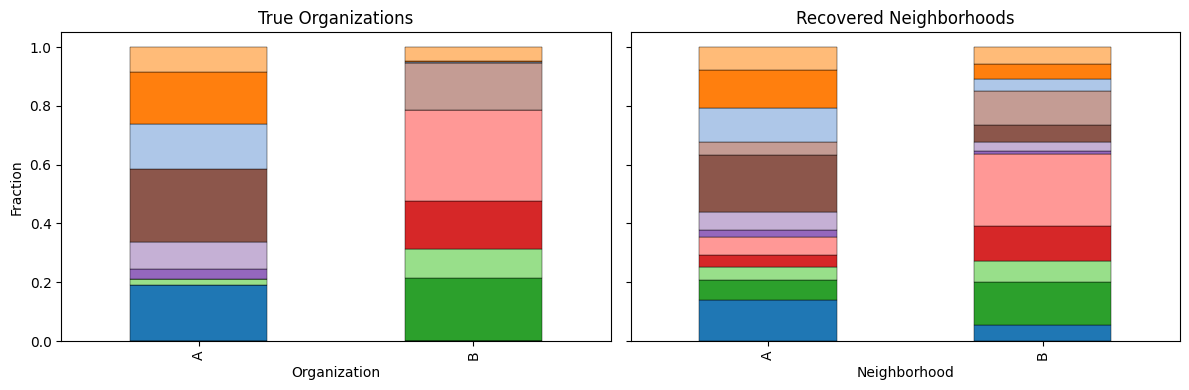

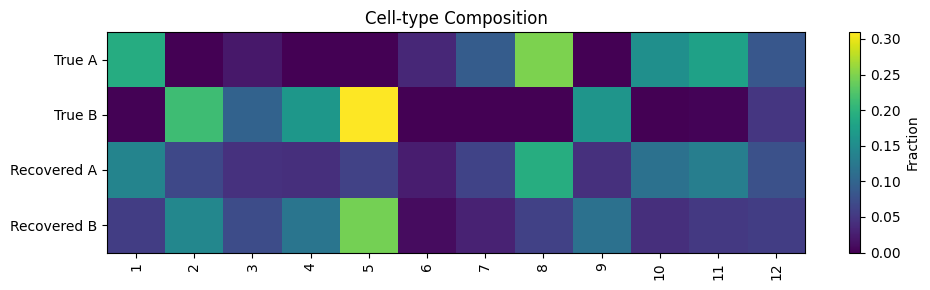

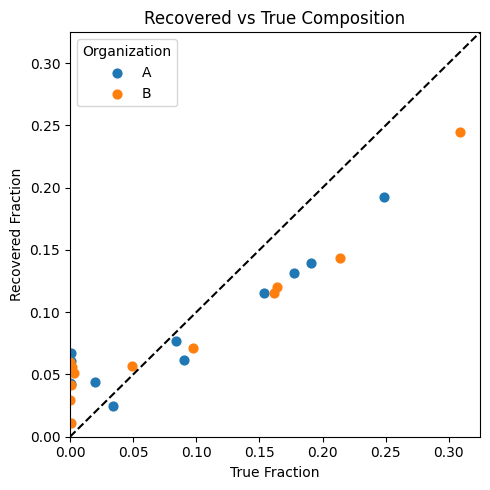

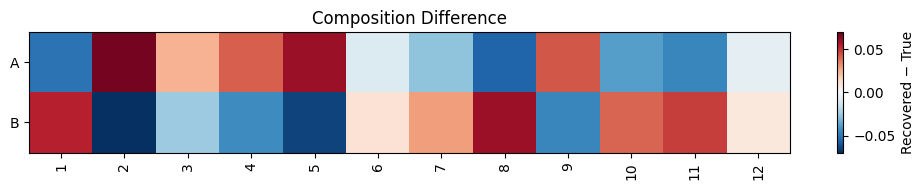


Composition Recovery

A: Pearson r = 0.9351, RMSE = 0.0433
B: Pearson r = 0.9578, RMSE = 0.0458


In [11]:
import anndata as ad

recovered = ad.read_h5ad(
    r"Z:\MINGLE\Reviewer Response\Code\R1.5\simslow_results.h5ad"
)

results = compare_neighborhood_composition(recovered, color_dict)

In [7]:
import numpy as np
import pandas as pd

from scipy.stats import pearsonr
from scipy.spatial.distance import jensenshannon


def compute_composition_metrics(
    df,
    true_col="true_organization",
    recovered_col="Neighborhood",
    cell_type_col="cell_type",
):
    """
    Compare true and recovered neighborhood cell-type compositions.

    Returns
    -------
    metrics : dict
        Summary statistics.

    true_comp : pd.DataFrame
        True cell-type proportions.

    recovered_comp : pd.DataFrame
        Recovered cell-type proportions.

    diff : pd.DataFrame
        recovered - true proportions.

    per_celltype_error : pd.DataFrame
        Absolute error for every organization × cell type.
    """

    ####################################################
    # Cell-type compositions
    ####################################################

    true_comp = pd.crosstab(
        df[true_col],
        df[cell_type_col],
        normalize="index"
    )

    recovered_comp = pd.crosstab(
        df[recovered_col],
        df[cell_type_col],
        normalize="index"
    )

    # ensure identical ordering

    true_comp = true_comp.sort_index().sort_index(axis=1)

    recovered_comp = recovered_comp.reindex(
        index=true_comp.index,
        columns=true_comp.columns,
        fill_value=0
    )

    ####################################################
    # Difference matrix
    ####################################################

    diff = recovered_comp - true_comp

    ####################################################
    # Statistics
    ####################################################

    rows = []

    for org in true_comp.index:

        truth = true_comp.loc[org].values.astype(float)
        pred = recovered_comp.loc[org].values.astype(float)

        r, p = pearsonr(truth, pred)

        r2 = r**2

        rmse = np.sqrt(
            np.mean((truth - pred) ** 2)
        )

        mae = np.mean(
            np.abs(truth - pred)
        )

        js = jensenshannon(
            truth,
            pred
        )

        max_abs = np.max(
            np.abs(truth - pred)
        )

        rows.append({

            "Organization": org,

            "Pearson_r": r,

            "Pearson_p": p,

            "R2": r2,

            "RMSE": rmse,

            "MAE": mae,

            "Jensen_Shannon": js,

            "Max_Absolute_Error": max_abs

        })

    metrics = pd.DataFrame(rows)

    ####################################################
    # Per-cell-type errors
    ####################################################

    errors = []

    for org in true_comp.index:

        for ct in true_comp.columns:

            errors.append({

                "Organization": org,

                "Cell_Type": ct,

                "True": true_comp.loc[org, ct],

                "Recovered": recovered_comp.loc[org, ct],

                "Difference": diff.loc[org, ct],

                "Absolute_Error": abs(
                    diff.loc[org, ct]
                )

            })

    per_celltype_error = pd.DataFrame(errors)

    return (
        metrics,
        true_comp,
        recovered_comp,
        diff,
        per_celltype_error,
    )

In [8]:
import numpy as np
import matplotlib.pyplot as plt


def plot_composition_scatter(
    metrics,
    true_comp,
    recovered_comp,
    color_dict,
):
    """
    Scatter plot comparing true vs recovered cell-type proportions.

    Marker shape = organization
    Marker color = cell type
    """

    fig, ax = plt.subplots(
        figsize=(6,6),
        dpi=300
    )

    ####################################################
    # Marker styles
    ####################################################

    markers = {
        "A": "s",   # square
        "B": "o",   # circle
    }

    xs = []
    ys = []

    ####################################################
    # Scatter
    ####################################################

    for org in true_comp.index:

        for ct in true_comp.columns:

            x = true_comp.loc[org, ct]
            y = recovered_comp.loc[org, ct]

            xs.append(x)
            ys.append(y)

            ax.scatter(
                x,
                y,
                s=80,
                marker=markers[org],
                color=color_dict[str(ct)],
                edgecolor="black",
                linewidth=0.5,
                zorder=3,
            )

    ####################################################
    # Identity line
    ####################################################

    lim = [
        0,
        max(max(xs), max(ys)) * 1.05,
    ]

    ax.plot(
        lim,
        lim,
        "--",
        color="black",
        linewidth=1,
    )

    ax.set_xlim(lim)
    ax.set_ylim(lim)

    ####################################################
    # Labels
    ####################################################

    ax.set_xlabel(
        "True Cell-Type Proportion",
        fontsize=12,
    )

    ax.set_ylabel(
        "Recovered Cell-Type Proportion",
        fontsize=12,
    )

    ax.set_title(
        "Recovered vs True Cell-Type Composition",
        fontsize=14,
    )

    ####################################################
    # Summary statistics
    ####################################################

    mean_r = metrics["Pearson_r"].mean()
    mean_r2 = metrics["R2"].mean()
    mean_rmse = metrics["RMSE"].mean()
    mean_mae = metrics["MAE"].mean()
    mean_js = metrics["Jensen_Shannon"].mean()
    mean_max = metrics["Max_Absolute_Error"].mean()

    stats_text = (
        f"Mean Pearson r = {mean_r:.3f}\n"
        f"Mean $R^2$ = {mean_r2:.3f}\n"
        f"Mean RMSE = {mean_rmse:.4f}\n"
        f"Mean MAE = {mean_mae:.4f}\n"
        f"Mean JS = {mean_js:.4f}\n"
        f"Max Error = {mean_max:.4f}"
    )

    ax.text(
        0.03,
        0.97,
        stats_text,
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=15,
        bbox=dict(
            facecolor="white",
            edgecolor="gray",
            alpha=0.9,
        ),
    )

    ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

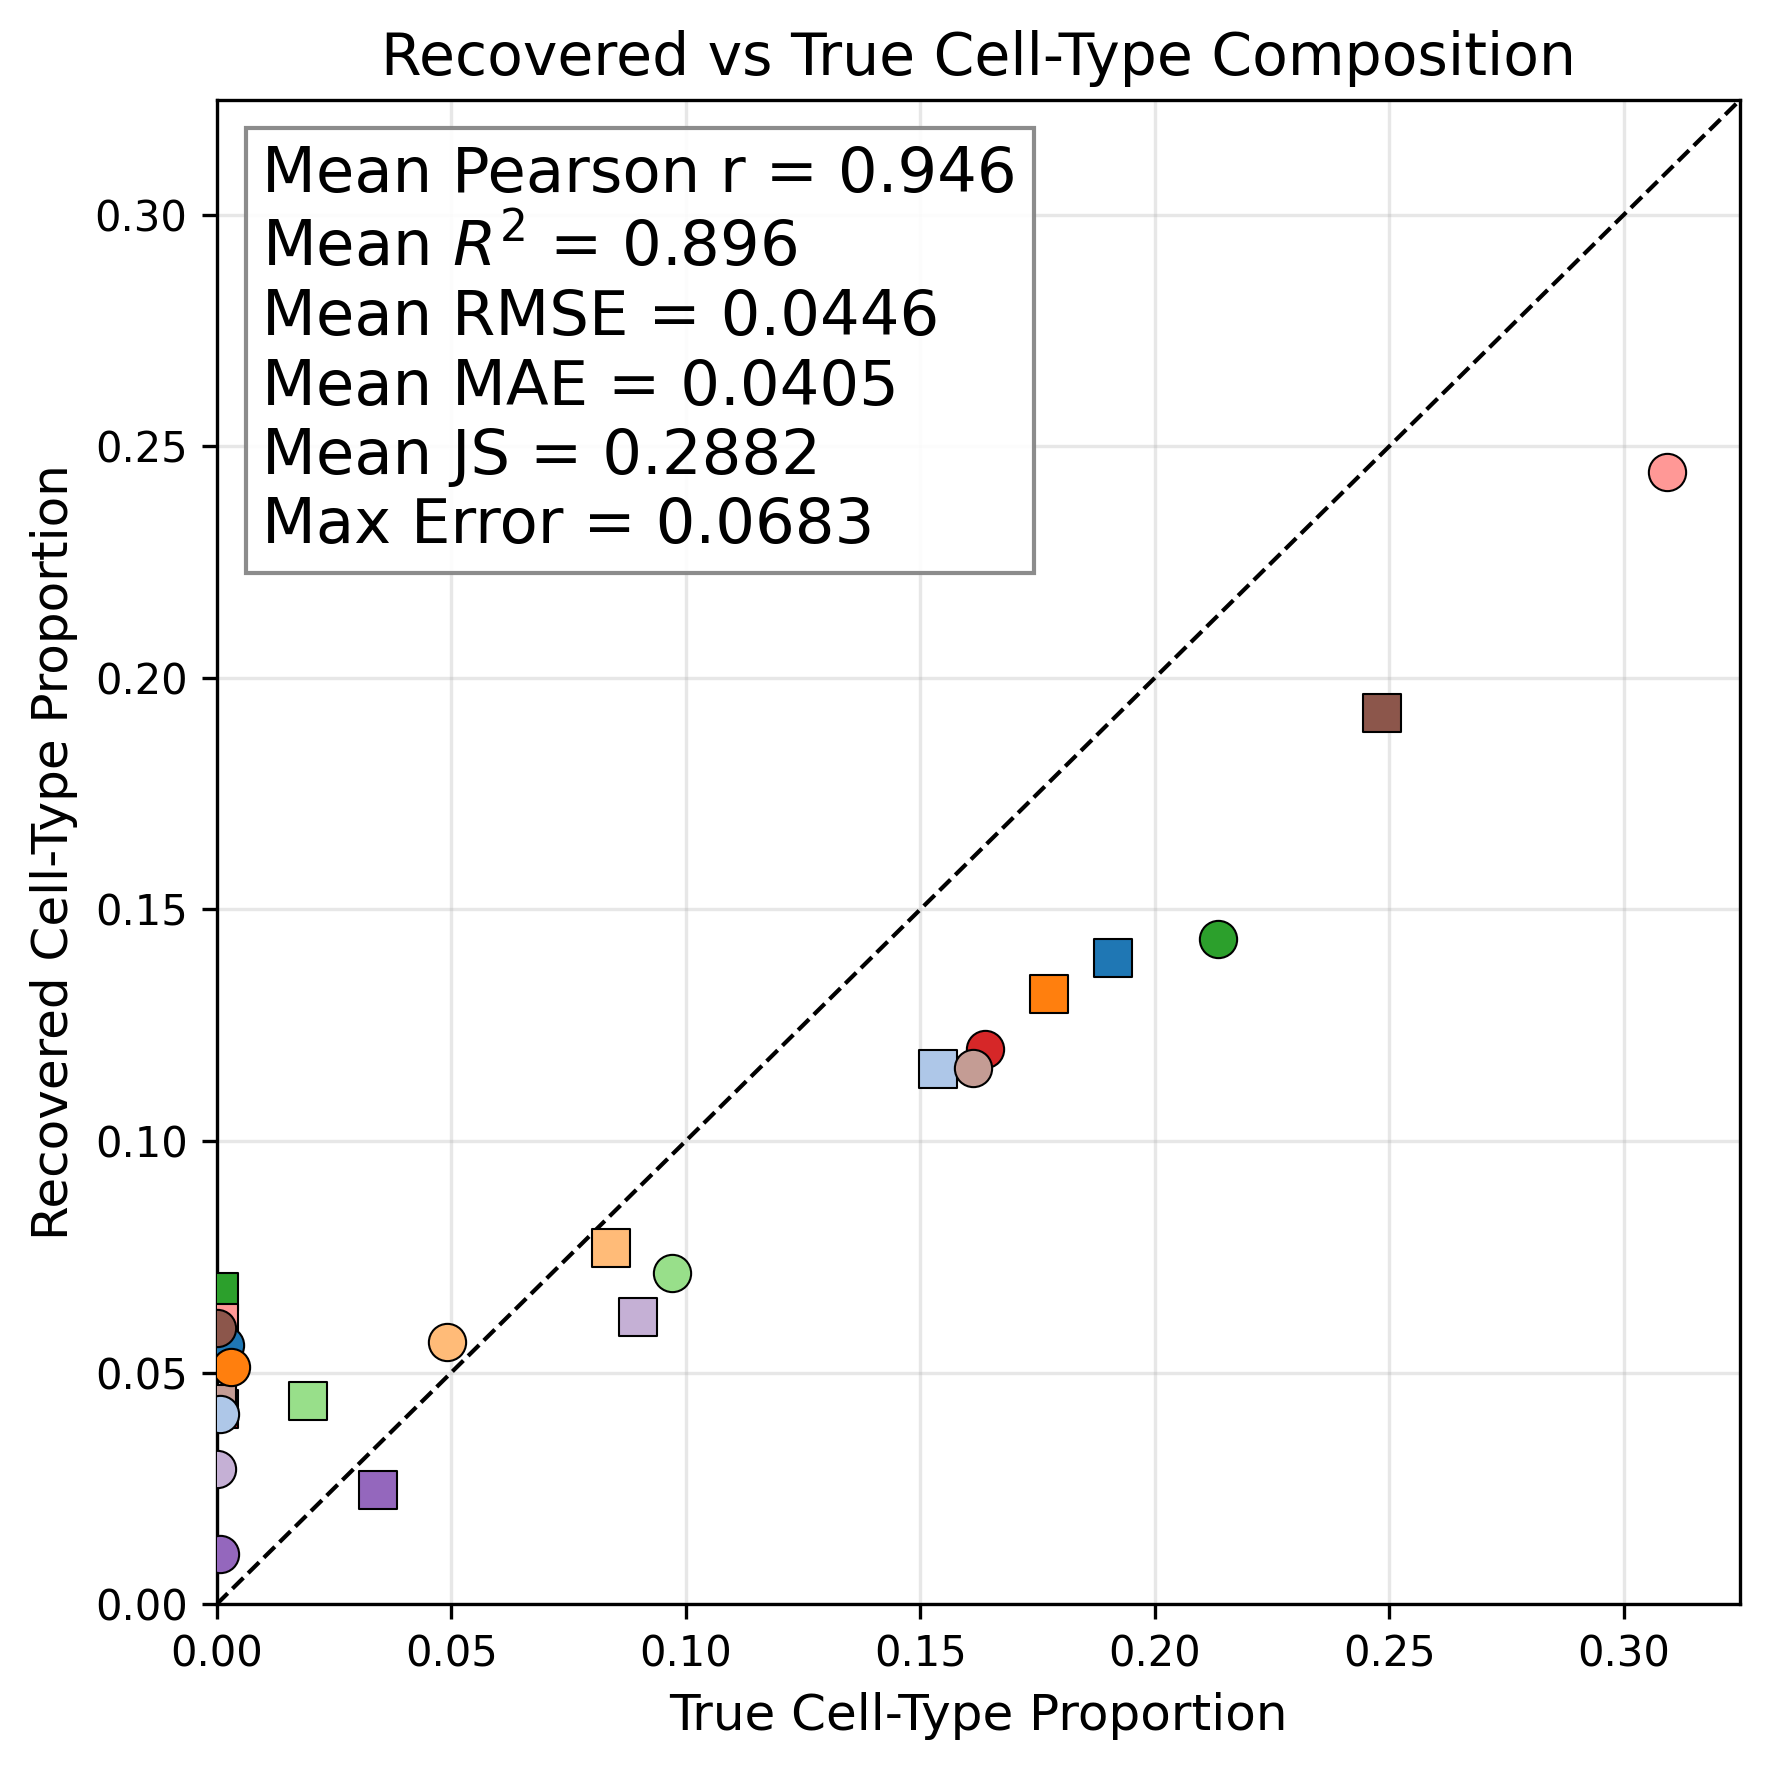

In [12]:
metrics, true_comp, recovered_comp, diff, errors = compute_composition_metrics(
    recovered.obs
)

plot_composition_scatter(
    metrics,
    true_comp,
    recovered_comp,
    color_dict,
)

In [10]:
print(recovered.filename)

None
